In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================
# Install & load small ESM2 model (t6_8M) for GPU-friendly embedding
# =========================
!pip install fair-esm

import torch
import esm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Load smaller ESM2 model (~8M params)
esm_model, esm_alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.to(device)
esm_model.eval()

batch_converter = esm_alphabet.get_batch_converter()
print("✅ Loaded ESM2-t6_8M model")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 4.6 MB/s eta 0:00:00
Device: cpu
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt
✅ Loaded ESM2-t6_8M model


In [ ]:
# =========================
# نصب پکیج‌های لازم
# =========================
!pip install fair-esm tqdm torch pandas

# =========================
# Imports
# =========================
import torch, os, pandas as pd
from tqdm import tqdm
from esm import pretrained

# =========================
# تنظیمات
# =========================
save_dir = "/content/drive/MyDrive/Untitled folder/embedding"
os.makedirs(save_dir, exist_ok=True)

train_csv_path = "/content/drive/MyDrive/Untitled folder/pepnn_train_dataset.csv"
test_csv_path  = "/content/drive/MyDrive/Untitled folder/pepnn_test_dataset.csv"

train_df = pd.read_csv(train_csv_path)
test_df  = pd.read_csv(test_csv_path)

train_protein_sequences = train_df['Receptor Sequence'].tolist()
train_pep_sequences     = train_df['Sequence'].tolist()
test_protein_sequences  = test_df['Receptor Sequence'].tolist()
test_pep_sequences      = test_df['Sequence'].tolist()

print(f"Train samples: {len(train_protein_sequences)} | Test samples: {len(test_protein_sequences)}")

# =========================
# مدل ESM2
# =========================
model, alphabet = pretrained.load_model_and_alphabet("esm2_t6_8M_UR50D")
batch_converter = alphabet.get_batch_converter()
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("✅ Loaded ESM2 8M model on", device)

# =========================
# تابع کمکی برای embedding
# =========================
@torch.no_grad()
def embed_sequences(seq_list, batch_size=4):
    """Return list of per-residue embeddings (L, D) for each sequence."""
    all_embeds = []
    for i in tqdm(range(0, len(seq_list), batch_size), desc="Embedding batches"):
        batch = seq_list[i:i+batch_size]
        batch_data = [("seq"+str(j), s) for j, s in enumerate(batch)]
        batch_labels, batch_strs, batch_tokens = batch_converter(batch_data)
        batch_tokens = batch_tokens.to(device)

        out = model(batch_tokens, repr_layers=[6])
        reps = out["representations"][6]

        for j, seq in enumerate(batch_strs):
            emb = reps[j, 1:len(seq)+1].cpu()
            all_embeds.append(emb)
    return all_embeds

# =========================
# تابع ذخیره‌سازی هر 1000 داده
# =========================
def save_batches(emb_list, prefix, kind, batch_size=1000):
    """Save batched embeddings or token lists to .pt files."""
    for i in range(0, len(emb_list), batch_size):
        batch = emb_list[i:i+batch_size]
        torch.save(batch, os.path.join(save_dir, f"{prefix}_{kind}_{i//batch_size:03d}.pt"))
    print(f"💾 Saved {len(emb_list)} items → {prefix}_{kind}_*.pt")

# =========================
# Embed datasets
# =========================
print("\n🚀 Embedding TRAIN proteins...")
train_prot_embs = embed_sequences(train_protein_sequences)
save_batches(train_prot_embs, "train", "prot_emb", batch_size=1000)

print("\n🚀 Embedding TRAIN peptides...")
train_pep_embs = embed_sequences(train_pep_sequences)
save_batches(train_pep_embs, "train", "pep_emb", batch_size=1000)

print("\n🚀 Embedding TEST proteins...")
test_prot_embs = embed_sequences(test_protein_sequences)
save_batches(test_prot_embs, "test", "prot_emb", batch_size=1000)

print("\n🚀 Embedding TEST peptides...")
test_pep_embs = embed_sequences(test_pep_sequences)
save_batches(test_pep_embs, "test", "pep_emb", batch_size=1000)

# =========================
# تولید توکن‌های پپتید
# =========================
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {aa: i for i, aa in enumerate(AA_LIST)}

def tokenize_sequences(seq_list):
    tokens = []
    for seq in seq_list:
        idxs = [aa_to_idx.get(aa, len(AA_LIST)) for aa in seq]
        tokens.append(torch.tensor(idxs, dtype=torch.long))
    return tokens

print("\n🔤 Tokenizing peptides...")
train_pep_tokens = tokenize_sequences(train_pep_sequences)
test_pep_tokens  = tokenize_sequences(test_pep_sequences)

save_batches(train_pep_tokens, "train", "pep_token", batch_size=1000)
save_batches(test_pep_tokens, "test", "pep_token", batch_size=1000)

print("\n🎉 همه‌ی فایل‌ها ساخته شدند در پوشه‌ی:")
print(save_dir)


Train samples: 2828 | Test samples: 92
✅ Loaded ESM2 8M model on cuda

🚀 Embedding TRAIN proteins...


Embedding batches: 100%|██████████| 707/707 [00:28<00:00, 24.87it/s]


💾 Saved 2828 items → train_prot_emb_*.pt

🚀 Embedding TRAIN peptides...


Embedding batches: 100%|██████████| 707/707 [00:08<00:00, 81.69it/s]


💾 Saved 2828 items → train_pep_emb_*.pt

🚀 Embedding TEST proteins...


Embedding batches: 100%|██████████| 23/23 [00:01<00:00, 14.41it/s]


💾 Saved 92 items → test_prot_emb_*.pt

🚀 Embedding TEST peptides...


Embedding batches: 100%|██████████| 23/23 [00:00<00:00, 57.98it/s]


💾 Saved 92 items → test_pep_emb_*.pt

🔤 Tokenizing peptides...
💾 Saved 2828 items → train_pep_token_*.pt
💾 Saved 92 items → test_pep_token_*.pt

🎉 همه‌ی فایل‌ها ساخته شدند در پوشه‌ی:
/content/drive/MyDrive/Untitled folder/embedding


In [ ]:
# =========================
# نصب پکیج‌های لازم
# =========================
!pip install fair-esm tqdm torch pandas

# =========================
# Imports
# =========================
import torch, os, pandas as pd
from tqdm import tqdm
from esm import pretrained

# =========================
# تنظیم پوشه ذخیره تست
# =========================
save_dir = "/content/drive/MyDrive/Untitled folder/embedding/test/embedding"
os.makedirs(save_dir, exist_ok=True)

# مسیر فایل تست
test_csv_path  = "/content/drive/MyDrive/Untitled folder/embedding/test/test.csv"

# =========================
# خواندن داده تست
# =========================
test_df  = pd.read_csv(test_csv_path)
test_protein_sequences  = test_df['Receptor Sequence'].tolist()
test_pep_sequences      = test_df['Binder'].tolist()

print(f"Test samples: {len(test_protein_sequences)}")

# =========================
# مدل ESM2
# =========================
model, alphabet = pretrained.load_model_and_alphabet("esm2_t6_8M_UR50D")
batch_converter = alphabet.get_batch_converter()
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("✅ Loaded ESM2 8M model on", device)

# =========================
# تابع کمکی embedding
# =========================
@torch.no_grad()
def embed_sequences(seq_list, batch_size=4):
    all_embeds = []
    for i in tqdm(range(0, len(seq_list), batch_size), desc="Embedding batches"):
        batch = seq_list[i:i+batch_size]
        batch_data = [("seq"+str(j), s) for j, s in enumerate(batch)]
        batch_labels, batch_strs, batch_tokens = batch_converter(batch_data)
        batch_tokens = batch_tokens.to(device)

        out = model(batch_tokens, repr_layers=[6])
        reps = out["representations"][6]

        for j, seq in enumerate(batch_strs):
            emb = reps[j, 1:len(seq)+1].cpu()
            all_embeds.append(emb)

    return all_embeds

# =========================
# تابع توکن‌سازی پپتید
# =========================
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {aa: i for i, aa in enumerate(AA_LIST)}
PAD_IDX = len(AA_LIST)

def tokenize_sequences(seq_list):
    tokens = []
    for seq in seq_list:
        idxs = [aa_to_idx.get(aa, PAD_IDX) for aa in seq]
        tokens.append(torch.tensor(idxs, dtype=torch.long))
    return tokens

# =========================
# تابع ذخیره هر 1000 آیتم
# =========================
def save_batches(emb_list, prefix, kind, batch_size=1000):
    for i in range(0, len(emb_list), batch_size):
        batch = emb_list[i:i+batch_size]
        torch.save(batch, os.path.join(save_dir, f"{prefix}_{kind}_{i//batch_size:03d}.pt"))
    print(f"💾 Saved {len(emb_list)} items → {prefix}_{kind}_*.pt")

# =========================
# EMBEDDING تست پروتئین و پپتید
# =========================
print("\n🚀 Embedding TEST proteins...")
test_prot_embs = embed_sequences(test_protein_sequences)
save_batches(test_prot_embs, "test", "prot_emb")

print("\n🚀 Embedding TEST peptides...")
test_pep_embs = embed_sequences(test_pep_sequences)
save_batches(test_pep_embs, "test", "pep_emb")

print("\n🔤 Tokenizing TEST peptides...")
test_pep_tokens = tokenize_sequences(test_pep_sequences)
save_batches(test_pep_tokens, "test", "pep_token")

print("\n🎉 همه فایل‌ها ساخته شدند در:")
print(save_dir)


Test samples: 203
✅ Loaded ESM2 8M model on cuda

🚀 Embedding TEST proteins...


Embedding batches: 100%|██████████| 51/51 [00:01<00:00, 27.84it/s]


💾 Saved 203 items → test_prot_emb_*.pt

🚀 Embedding TEST peptides...


Embedding batches: 100%|██████████| 51/51 [00:00<00:00, 111.93it/s]

💾 Saved 203 items → test_pep_emb_*.pt

🔤 Tokenizing TEST peptides...
💾 Saved 203 items → test_pep_token_*.pt

🎉 همه فایل‌ها ساخته شدند در:
/content/drive/MyDrive/Untitled folder/embedding/test/embedding


In [ ]:
# ============================================
# Pretraining Decoder on Precomputed ESM Embeddings
# ============================================
import torch, gc, time, glob
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧩 Device:", device)

# ---------------- Settings ----------------
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
PAD_IDX = len(AA_LIST)
vocab_size = len(AA_LIST) + 1

token_dim = 320      # ESM output dim
prot_dim  = 320
batch_size = 8
epochs = 50
lr = 1e-4
patience = 12

best_model_path = "/kaggle/working/best_decoder_pretrain.pt"

# ---------------- No ESM Needed ----------------
# You already computed embeddings → remove esm_model completely
esm_proj = nn.Linear(prot_dim, token_dim).to(device)

# ---------------- Dataset ----------------
class BatchEmbeddingDataset(Dataset):
    def __init__(self, prot_files, pep_token_files):
        self.prot_batches = [torch.load(f, map_location='cpu') for f in prot_files]
        self.pep_token_batches = [torch.load(f, map_location='cpu') for f in pep_token_files]
        self.lengths = [len(t) for t in self.pep_token_batches]
        self.cum_lengths = torch.cumsum(torch.tensor(self.lengths), dim=0)

    def __len__(self):
        return int(self.cum_lengths[-1])

    def __getitem__(self, idx):
        file_idx = int((self.cum_lengths > idx).nonzero()[0])
        inner_idx = idx if file_idx == 0 else idx - int(self.cum_lengths[file_idx-1])

        prot_emb = self.prot_batches[file_idx][inner_idx].float()     # (L, 320)
        pep_tokens = self.pep_token_batches[file_idx][inner_idx].long() # (T)

        return prot_emb, pep_tokens

def collate_fn(batch):
    prots, pep_tokens = zip(*batch)
    B = len(prots)

    # -------- Pad protein embeddings --------
    Lp = max(p.shape[0] for p in prots)
    Dp = prots[0].shape[1]
    prot_pad = torch.zeros(B, Lp, Dp, device=device)
    for i, p in enumerate(prots):
        prot_pad[i, :p.shape[0]] = p.to(device)

    # -------- Pad peptide token sequence --------
    Ltok = max(len(t) for t in pep_tokens)
    pep_token_pad = torch.full((B, Ltok), PAD_IDX, dtype=torch.long, device=device)
    for i, t in enumerate(pep_tokens):
        pep_token_pad[i, :len(t)] = t.to(device)

    return prot_pad, pep_token_pad


# ---------------- Load dataset ----------------
train_prot_files = sorted(glob.glob("/train_prot_emb_*.pt"))
train_pep_token_files = sorted(glob.glob("/kaggle/working/emb-final/train_pep_token_*.pt"))

val_prot_files   = sorted(glob.glob("/kaggle/working/emb-final/test_prot_emb_*.pt"))
val_pep_token_files = sorted(glob.glob("/kaggle/working/emb-final/test_pep_token_*.pt"))

train_dataset = BatchEmbeddingDataset(train_prot_files, train_pep_token_files)
val_dataset   = BatchEmbeddingDataset(val_prot_files, val_pep_token_files)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                          collate_fn=collate_fn)

# ---------------- Decoder ----------------
class UnembedDecoder(nn.Module):
    def __init__(self, token_dim, vocab_size, hidden_dim=512, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(token_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, vocab_size)
        )
    def forward(self, x):
        return self.net(x)

decoder = UnembedDecoder(token_dim, vocab_size).to(device)

# ---------------- Helper: embed protein (mean pooling only) ----------------
def esm_embed_prot(prot_pad):
    """
    prot_pad: [B, L, 320]
    return:   [B, 320]
    """
    rep = prot_pad.mean(dim=1)
    return esm_proj(rep)

# ---------------- Optimizer ----------------
opt = torch.optim.AdamW(
    list(decoder.parameters()) + list(esm_proj.parameters()),
    lr=lr, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode='min', factor=0.5, patience=3
)

# ---------------- Training Loop ----------------
best_val = float("inf")
epochs_no_improve = 0

for epoch in range(1, epochs+1):

    decoder.train()
    tr_loss = 0.0

    for prot_pad, pep_token_pad in tqdm(train_loader, desc=f"Train {epoch}"):
        B = prot_pad.size(0)

        # (B, 320)
        x_emb = esm_embed_prot(prot_pad)

        # expand → (B, T, 320)
        x_emb = x_emb.unsqueeze(1).expand(B, pep_token_pad.size(1), token_dim)

        logits = decoder(x_emb)

        loss = F.cross_entropy(
            logits.reshape(-1, vocab_size),
            pep_token_pad.reshape(-1),
            ignore_index=PAD_IDX
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
        opt.step()
        opt.zero_grad()

        tr_loss += loss.item()

    # ---------------- Validation ----------------
    decoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for prot_pad, pep_token_pad in val_loader:
            B = prot_pad.size(0)
            x_emb = esm_embed_prot(prot_pad)
            x_emb = x_emb.unsqueeze(1).expand(B, pep_token_pad.size(1), token_dim)
            logits = decoder(x_emb)

            loss = F.cross_entropy(
                logits.reshape(-1, vocab_size),
                pep_token_pad.reshape(-1),
                ignore_index=PAD_IDX
            )
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch}: Train={tr_loss/len(train_loader):.4f} | Val={val_loss:.4f}")
    scheduler.step(val_loss)

    # Save best
    if val_loss < best_val:
        best_val = val_loss
        epochs_no_improve = 0
        torch.save({
            "decoder": decoder.state_dict(),
            "esm_proj": esm_proj.state_dict(),
        }, best_model_path)
        print("💾 Best model saved.")

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print("⏹️ Early stopping.")
        break

    gc.collect()
    torch.cuda.empty_cache()

print("🏁 Pretraining finished.")


In [ ]:
# =========================
# نصب پکیج‌های لازم
# =========================
!pip install fair-esm tqdm torch pandas

# =========================
# Imports
# =========================
import torch, os, pandas as pd
from tqdm import tqdm
from esm import pretrained

# =========================
# تنظیمات
# =========================
save_dir = "/content/drive/MyDrive/Untitled folder/embedding"
os.makedirs(save_dir, exist_ok=True)

train_csv_path = "/content/drive/MyDrive/Untitled folder/pepnn_train_dataset.csv"
test_csv_path  = "/content/drive/MyDrive/Untitled folder/pepnn_test_dataset.csv"

train_df = pd.read_csv(train_csv_path)
test_df  = pd.read_csv(test_csv_path)

train_protein_sequences = train_df['Receptor Sequence'].tolist()
train_pep_sequences     = train_df['Sequence'].tolist()
test_protein_sequences  = test_df['Receptor Sequence'].tolist()
test_pep_sequences      = test_df['Sequence'].tolist()

print(f"Train samples: {len(train_protein_sequences)} | Test samples: {len(test_protein_sequences)}")

# =========================
# مدل ESM2
# =========================
model, alphabet = pretrained.load_model_and_alphabet("esm2_t6_8M_UR50D")
batch_converter = alphabet.get_batch_converter()
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("✅ Loaded ESM2 8M model on", device)

# =========================
# تابع کمکی برای embedding
# =========================
@torch.no_grad()
def embed_sequences(seq_list, batch_size=4):
    """Return list of per-residue embeddings (L, D) for each sequence."""
    all_embeds = []
    for i in tqdm(range(0, len(seq_list), batch_size), desc="Embedding batches"):
        batch = seq_list[i:i+batch_size]
        batch_data = [("seq"+str(j), s) for j, s in enumerate(batch)]
        batch_labels, batch_strs, batch_tokens = batch_converter(batch_data)
        batch_tokens = batch_tokens.to(device)

        out = model(batch_tokens, repr_layers=[6])
        reps = out["representations"][6]

        for j, seq in enumerate(batch_strs):
            emb = reps[j, 1:len(seq)+1].cpu()
            all_embeds.append(emb)
    return all_embeds

# =========================
# تابع ذخیره‌سازی هر 1000 داده
# =========================
def save_batches(emb_list, prefix, kind, batch_size=1000):
    """Save batched embeddings or token lists to .pt files."""
    for i in range(0, len(emb_list), batch_size):
        batch = emb_list[i:i+batch_size]
        torch.save(batch, os.path.join(save_dir, f"{prefix}_{kind}_{i//batch_size:03d}.pt"))
    print(f"💾 Saved {len(emb_list)} items → {prefix}_{kind}_*.pt")

# =========================
# Embed datasets
# =========================
print("\n🚀 Embedding TRAIN proteins...")
train_prot_embs = embed_sequences(train_protein_sequences)
save_batches(train_prot_embs, "train", "prot_emb", batch_size=1000)

print("\n🚀 Embedding TRAIN peptides...")
train_pep_embs = embed_sequences(train_pep_sequences)
save_batches(train_pep_embs, "train", "pep_emb", batch_size=1000)

print("\n🚀 Embedding TEST proteins...")
test_prot_embs = embed_sequences(test_protein_sequences)
save_batches(test_prot_embs, "test", "prot_emb", batch_size=1000)

print("\n🚀 Embedding TEST peptides...")
test_pep_embs = embed_sequences(test_pep_sequences)
save_batches(test_pep_embs, "test", "pep_emb", batch_size=1000)

# =========================
# تولید توکن‌های پپتید
# =========================
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {aa: i for i, aa in enumerate(AA_LIST)}

def tokenize_sequences(seq_list):
    tokens = []
    for seq in seq_list:
        idxs = [aa_to_idx.get(aa, len(AA_LIST)) for aa in seq]
        tokens.append(torch.tensor(idxs, dtype=torch.long))
    return tokens

print("\n🔤 Tokenizing peptides...")
train_pep_tokens = tokenize_sequences(train_pep_sequences)
test_pep_tokens  = tokenize_sequences(test_pep_sequences)

save_batches(train_pep_tokens, "train", "pep_token", batch_size=1000)
save_batches(test_pep_tokens, "test", "pep_token", batch_size=1000)

print("\n🎉 همه‌ی فایل‌ها ساخته شدند در پوشه‌ی:")
print(save_dir)


Train samples: 2828 | Test samples: 92
✅ Loaded ESM2 8M model on cuda

🚀 Embedding TRAIN proteins...


Embedding batches: 100%|██████████| 707/707 [00:28<00:00, 24.87it/s]


💾 Saved 2828 items → train_prot_emb_*.pt

🚀 Embedding TRAIN peptides...


Embedding batches: 100%|██████████| 707/707 [00:08<00:00, 81.69it/s]


💾 Saved 2828 items → train_pep_emb_*.pt

🚀 Embedding TEST proteins...


Embedding batches: 100%|██████████| 23/23 [00:01<00:00, 14.41it/s]


💾 Saved 92 items → test_prot_emb_*.pt

🚀 Embedding TEST peptides...


Embedding batches: 100%|██████████| 23/23 [00:00<00:00, 57.98it/s]


💾 Saved 92 items → test_pep_emb_*.pt

🔤 Tokenizing peptides...
💾 Saved 2828 items → train_pep_token_*.pt
💾 Saved 92 items → test_pep_token_*.pt

🎉 همه‌ی فایل‌ها ساخته شدند در پوشه‌ی:
/content/drive/MyDrive/Untitled folder/embedding


In [ ]:
# =========================
# نصب پکیج‌های لازم
# =========================
!pip install fair-esm tqdm torch pandas

# =========================
# Imports
# =========================
import torch, os, pandas as pd
from tqdm import tqdm
from esm import pretrained

# =========================
# تنظیمات
# =========================
save_dir = "/content/drive/MyDrive/Untitled folder/embedding"
os.makedirs(save_dir, exist_ok=True)

train_csv_path = "/content/drive/MyDrive/Untitled folder/pepnn_train_dataset.csv"
test_csv_path  = "/content/drive/MyDrive/Untitled folder/pepnn_test_dataset.csv"

train_df = pd.read_csv(train_csv_path)
test_df  = pd.read_csv(test_csv_path)

train_protein_sequences = train_df['Receptor Sequence'].tolist()
train_pep_sequences     = train_df['Sequence'].tolist()
test_protein_sequences  = test_df['Receptor Sequence'].tolist()
test_pep_sequences      = test_df['Sequence'].tolist()

print(f"Train samples: {len(train_protein_sequences)} | Test samples: {len(test_protein_sequences)}")

# =========================
# مدل ESM2
# =========================
model, alphabet = pretrained.load_model_and_alphabet("esm2_t6_8M_UR50D")
batch_converter = alphabet.get_batch_converter()
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("✅ Loaded ESM2 8M model on", device)

# =========================
# تابع کمکی برای embedding
# =========================
@torch.no_grad()
def embed_sequences(seq_list, batch_size=4):
    """Return list of per-residue embeddings (L, D) for each sequence."""
    all_embeds = []
    for i in tqdm(range(0, len(seq_list), batch_size), desc="Embedding batches"):
        batch = seq_list[i:i+batch_size]
        batch_data = [("seq"+str(j), s) for j, s in enumerate(batch)]
        batch_labels, batch_strs, batch_tokens = batch_converter(batch_data)
        batch_tokens = batch_tokens.to(device)

        out = model(batch_tokens, repr_layers=[6])
        reps = out["representations"][6]

        for j, seq in enumerate(batch_strs):
            emb = reps[j, 1:len(seq)+1].cpu()
            all_embeds.append(emb)
    return all_embeds

# =========================
# تابع ذخیره‌سازی هر 1000 داده
# =========================
def save_batches(emb_list, prefix, kind, batch_size=1000):
    """Save batched embeddings or token lists to .pt files."""
    for i in range(0, len(emb_list), batch_size):
        batch = emb_list[i:i+batch_size]
        torch.save(batch, os.path.join(save_dir, f"{prefix}_{kind}_{i//batch_size:03d}.pt"))
    print(f"💾 Saved {len(emb_list)} items → {prefix}_{kind}_*.pt")

# =========================
# Embed datasets
# =========================
print("\n🚀 Embedding TRAIN proteins...")
train_prot_embs = embed_sequences(train_protein_sequences)
save_batches(train_prot_embs, "train", "prot_emb", batch_size=1000)

print("\n🚀 Embedding TRAIN peptides...")
train_pep_embs = embed_sequences(train_pep_sequences)
save_batches(train_pep_embs, "train", "pep_emb", batch_size=1000)

print("\n🚀 Embedding TEST proteins...")
test_prot_embs = embed_sequences(test_protein_sequences)
save_batches(test_prot_embs, "test", "prot_emb", batch_size=1000)

print("\n🚀 Embedding TEST peptides...")
test_pep_embs = embed_sequences(test_pep_sequences)
save_batches(test_pep_embs, "test", "pep_emb", batch_size=1000)

# =========================
# تولید توکن‌های پپتید
# =========================
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {aa: i for i, aa in enumerate(AA_LIST)}

def tokenize_sequences(seq_list):
    tokens = []
    for seq in seq_list:
        idxs = [aa_to_idx.get(aa, len(AA_LIST)) for aa in seq]
        tokens.append(torch.tensor(idxs, dtype=torch.long))
    return tokens

print("\n🔤 Tokenizing peptides...")
train_pep_tokens = tokenize_sequences(train_pep_sequences)
test_pep_tokens  = tokenize_sequences(test_pep_sequences)

save_batches(train_pep_tokens, "train", "pep_token", batch_size=1000)
save_batches(test_pep_tokens, "test", "pep_token", batch_size=1000)

print("\n🎉 همه‌ی فایل‌ها ساخته شدند در پوشه‌ی:")
print(save_dir)


Train samples: 2828 | Test samples: 92
✅ Loaded ESM2 8M model on cuda

🚀 Embedding TRAIN proteins...


Embedding batches: 100%|██████████| 707/707 [00:28<00:00, 24.87it/s]


💾 Saved 2828 items → train_prot_emb_*.pt

🚀 Embedding TRAIN peptides...


Embedding batches: 100%|██████████| 707/707 [00:08<00:00, 81.69it/s]


💾 Saved 2828 items → train_pep_emb_*.pt

🚀 Embedding TEST proteins...


Embedding batches: 100%|██████████| 23/23 [00:01<00:00, 14.41it/s]


💾 Saved 92 items → test_prot_emb_*.pt

🚀 Embedding TEST peptides...


Embedding batches: 100%|██████████| 23/23 [00:00<00:00, 57.98it/s]


💾 Saved 92 items → test_pep_emb_*.pt

🔤 Tokenizing peptides...
💾 Saved 2828 items → train_pep_token_*.pt
💾 Saved 92 items → test_pep_token_*.pt

🎉 همه‌ی فایل‌ها ساخته شدند در پوشه‌ی:
/content/drive/MyDrive/Untitled folder/embedding


In [ ]:
# =========================
# نصب پکیج‌های لازم
# =========================
!pip install fair-esm tqdm torch pandas

# =========================
# Imports
# =========================
import torch, os, pandas as pd
from tqdm import tqdm
from esm import pretrained

# =========================
# تنظیمات
# =========================
save_dir = "/content/drive/MyDrive/Untitled folder/embedding"
os.makedirs(save_dir, exist_ok=True)

train_csv_path = "/content/drive/MyDrive/Untitled folder/pepnn_train_dataset.csv"
test_csv_path  = "/content/drive/MyDrive/Untitled folder/pepnn_test_dataset.csv"

train_df = pd.read_csv(train_csv_path)
test_df  = pd.read_csv(test_csv_path)

train_protein_sequences = train_df['Receptor Sequence'].tolist()
train_pep_sequences     = train_df['Sequence'].tolist()
test_protein_sequences  = test_df['Receptor Sequence'].tolist()
test_pep_sequences      = test_df['Sequence'].tolist()

print(f"Train samples: {len(train_protein_sequences)} | Test samples: {len(test_protein_sequences)}")

# =========================
# مدل ESM2
# =========================
model, alphabet = pretrained.load_model_and_alphabet("esm2_t6_8M_UR50D")
batch_converter = alphabet.get_batch_converter()
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("✅ Loaded ESM2 8M model on", device)

# =========================
# تابع کمکی برای embedding
# =========================
@torch.no_grad()
def embed_sequences(seq_list, batch_size=4):
    """Return list of per-residue embeddings (L, D) for each sequence."""
    all_embeds = []
    for i in tqdm(range(0, len(seq_list), batch_size), desc="Embedding batches"):
        batch = seq_list[i:i+batch_size]
        batch_data = [("seq"+str(j), s) for j, s in enumerate(batch)]
        batch_labels, batch_strs, batch_tokens = batch_converter(batch_data)
        batch_tokens = batch_tokens.to(device)

        out = model(batch_tokens, repr_layers=[6])
        reps = out["representations"][6]

        for j, seq in enumerate(batch_strs):
            emb = reps[j, 1:len(seq)+1].cpu()
            all_embeds.append(emb)
    return all_embeds

# =========================
# تابع ذخیره‌سازی هر 1000 داده
# =========================
def save_batches(emb_list, prefix, kind, batch_size=1000):
    """Save batched embeddings or token lists to .pt files."""
    for i in range(0, len(emb_list), batch_size):
        batch = emb_list[i:i+batch_size]
        torch.save(batch, os.path.join(save_dir, f"{prefix}_{kind}_{i//batch_size:03d}.pt"))
    print(f"💾 Saved {len(emb_list)} items → {prefix}_{kind}_*.pt")

# =========================
# Embed datasets
# =========================
print("\n🚀 Embedding TRAIN proteins...")
train_prot_embs = embed_sequences(train_protein_sequences)
save_batches(train_prot_embs, "train", "prot_emb", batch_size=1000)

print("\n🚀 Embedding TRAIN peptides...")
train_pep_embs = embed_sequences(train_pep_sequences)
save_batches(train_pep_embs, "train", "pep_emb", batch_size=1000)

print("\n🚀 Embedding TEST proteins...")
test_prot_embs = embed_sequences(test_protein_sequences)
save_batches(test_prot_embs, "test", "prot_emb", batch_size=1000)

print("\n🚀 Embedding TEST peptides...")
test_pep_embs = embed_sequences(test_pep_sequences)
save_batches(test_pep_embs, "test", "pep_emb", batch_size=1000)

# =========================
# تولید توکن‌های پپتید
# =========================
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {aa: i for i, aa in enumerate(AA_LIST)}

def tokenize_sequences(seq_list):
    tokens = []
    for seq in seq_list:
        idxs = [aa_to_idx.get(aa, len(AA_LIST)) for aa in seq]
        tokens.append(torch.tensor(idxs, dtype=torch.long))
    return tokens

print("\n🔤 Tokenizing peptides...")
train_pep_tokens = tokenize_sequences(train_pep_sequences)
test_pep_tokens  = tokenize_sequences(test_pep_sequences)

save_batches(train_pep_tokens, "train", "pep_token", batch_size=1000)
save_batches(test_pep_tokens, "test", "pep_token", batch_size=1000)

print("\n🎉 همه‌ی فایل‌ها ساخته شدند در پوشه‌ی:")
print(save_dir)


Train samples: 2828 | Test samples: 92
✅ Loaded ESM2 8M model on cuda

🚀 Embedding TRAIN proteins...


Embedding batches: 100%|██████████| 707/707 [00:28<00:00, 24.87it/s]


💾 Saved 2828 items → train_prot_emb_*.pt

🚀 Embedding TRAIN peptides...


Embedding batches: 100%|██████████| 707/707 [00:08<00:00, 81.69it/s]


💾 Saved 2828 items → train_pep_emb_*.pt

🚀 Embedding TEST proteins...


Embedding batches: 100%|██████████| 23/23 [00:01<00:00, 14.41it/s]


💾 Saved 92 items → test_prot_emb_*.pt

🚀 Embedding TEST peptides...


Embedding batches: 100%|██████████| 23/23 [00:00<00:00, 57.98it/s]


💾 Saved 92 items → test_pep_emb_*.pt

🔤 Tokenizing peptides...
💾 Saved 2828 items → train_pep_token_*.pt
💾 Saved 92 items → test_pep_token_*.pt

🎉 همه‌ی فایل‌ها ساخته شدند در پوشه‌ی:
/content/drive/MyDrive/Untitled folder/embedding


In [ ]:
# ============================================
# Pretraining Transformer Decoder on Precomputed ESM Embeddings
# ============================================
import torch, gc, time, glob
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧩 Device:", device)

# ---------------- Settings ----------------
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
PAD_IDX = len(AA_LIST)
vocab_size = len(AA_LIST) + 1

token_dim = 320      # ESM output dim
prot_dim  = 320
batch_size = 8
epochs = 50
lr = 1e-4
patience = 12

best_model_path = "/content/drive/MyDrive/Untitled folder/best_decoder_pretrain.pt"

# ---------------- No ESM Needed ----------------
# You already computed embeddings → remove esm_model completely
esm_proj = nn.Linear(prot_dim, token_dim).to(device)

# ---------------- Dataset ----------------
class BatchEmbeddingDataset(Dataset):
    def __init__(self, prot_files, pep_token_files):
        self.prot_batches = [torch.load(f, map_location='cpu') for f in prot_files]
        self.pep_token_batches = [torch.load(f, map_location='cpu') for f in pep_token_files]
        self.lengths = [len(t) for t in self.pep_token_batches]
        self.cum_lengths = torch.cumsum(torch.tensor(self.lengths), dim=0)

    def __len__(self):
        return int(self.cum_lengths[-1])

    def __getitem__(self, idx):
        file_idx = int((self.cum_lengths > idx).nonzero()[0])
        inner_idx = idx if file_idx == 0 else idx - int(self.cum_lengths[file_idx-1])
        prot_emb = self.prot_batches[file_idx][inner_idx].float()     # (L, 320)
        pep_tokens = self.pep_token_batches[file_idx][inner_idx].long() # (T)
        return prot_emb, pep_tokens

def collate_fn(batch):
    prots, pep_tokens = zip(*batch)
    B = len(prots)

    # -------- Pad protein embeddings --------
    Lp = max(p.shape[0] for p in prots)
    Dp = prots[0].shape[1]
    prot_pad = torch.zeros(B, Lp, Dp, device=device)
    for i, p in enumerate(prots):
        prot_pad[i, :p.shape[0]] = p.to(device)

    # -------- Pad peptide token sequence --------
    Ltok = max(len(t) for t in pep_tokens)
    pep_token_pad = torch.full((B, Ltok), PAD_IDX, dtype=torch.long, device=device)
    for i, t in enumerate(pep_tokens):
        pep_token_pad[i, :len(t)] = t.to(device)

    return prot_pad, pep_token_pad

# ---------------- Load dataset ----------------
train_prot_files = sorted(glob.glob("/content/drive/MyDrive/Untitled folder/embedding/train_prot_emb_*.pt"))
train_pep_token_files = sorted(glob.glob("/content/drive/MyDrive/Untitled folder/embedding/train_pep_token_*.pt"))

val_prot_files   = sorted(glob.glob("/content/drive/MyDrive/Untitled folder/embedding/test_prot_emb_*.pt"))
val_pep_token_files = sorted(glob.glob("/content/drive/MyDrive/Untitled folder/embedding/test_pep_token_*.pt"))

train_dataset = BatchEmbeddingDataset(train_prot_files, train_pep_token_files)
val_dataset   = BatchEmbeddingDataset(val_prot_files, val_pep_token_files)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                          collate_fn=collate_fn)

# ---------------- Transformer Decoder ----------------
class TransformerDecoder(nn.Module):
    def __init__(self, token_dim, vocab_size, nhead=8, nlayer=4, max_len=512, dropout=0.1):
        super().__init__()
        self.token_dim = token_dim
        self.pos_emb = nn.Parameter(torch.randn(1, max_len, token_dim))  # positional embedding
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=token_dim,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayer)
        self.out = nn.Linear(token_dim, vocab_size)

    def forward(self, x):
        B, L, D = x.shape
        x = x + self.pos_emb[:, :L, :]
        x = self.transformer(x)
        logits = self.out(x)
        return logits

decoder = TransformerDecoder(token_dim, vocab_size).to(device)

# ---------------- Helper: embed protein (mean pooling only) ----------------
def esm_embed_prot(prot_pad):
    rep = prot_pad.mean(dim=1)  # [B, 320]
    return esm_proj(rep)

# ---------------- Optimizer ----------------
opt = torch.optim.AdamW(
    list(decoder.parameters()) + list(esm_proj.parameters()),
    lr=lr, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode='min', factor=0.5, patience=3
)

# ---------------- Training Loop ----------------
best_val = float("inf")
epochs_no_improve = 0

for epoch in range(1, epochs+1):

    decoder.train()
    tr_loss = 0.0

    for prot_pad, pep_token_pad in tqdm(train_loader, desc=f"Train {epoch}"):
        B = prot_pad.size(0)
        x_emb = esm_embed_prot(prot_pad)                # [B, 320]
        x_emb = x_emb.unsqueeze(1).expand(B, pep_token_pad.size(1), token_dim)  # [B, T, 320]

        logits = decoder(x_emb)

        loss = F.cross_entropy(
            logits.reshape(-1, vocab_size),
            pep_token_pad.reshape(-1),
            ignore_index=PAD_IDX
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
        opt.step()
        opt.zero_grad()

        tr_loss += loss.item()

    # ---------------- Validation ----------------
    decoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for prot_pad, pep_token_pad in val_loader:
            B = prot_pad.size(0)
            x_emb = esm_embed_prot(prot_pad)
            x_emb = x_emb.unsqueeze(1).expand(B, pep_token_pad.size(1), token_dim)
            logits = decoder(x_emb)
            loss = F.cross_entropy(
                logits.reshape(-1, vocab_size),
                pep_token_pad.reshape(-1),
                ignore_index=PAD_IDX
            )
            val_loss += loss.item()

    val_loss /= len(val_loader)
    print(f"Epoch {epoch}: Train={tr_loss/len(train_loader):.4f} | Val={val_loss:.4f}")
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        epochs_no_improve = 0
        torch.save({
            "decoder": decoder.state_dict(),
            "esm_proj": esm_proj.state_dict(),
        }, best_model_path)
        print("💾 Best model saved.")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print("⏹️ Early stopping.")
        break

    gc.collect()
    torch.cuda.empty_cache()

print("🏁 Pretraining finished.")


🧩 Device: cuda


Train 1: 100%|██████████| 354/354 [00:06<00:00, 55.26it/s]


Epoch 1: Train=2.9132 | Val=2.9071
💾 Best model saved.


Train 2: 100%|██████████| 354/354 [00:05<00:00, 65.59it/s]


Epoch 2: Train=2.8790 | Val=2.9120


...

Epoch 18: Train=2.5988 | Val=2.9288


Train 19: 100%|██████████| 354/354 [00:06<00:00, 56.03it/s]


Epoch 19: Train=2.5844 | Val=2.9466


Train 20: 100%|██████████| 354/354 [00:05<00:00, 65.81it/s]


Epoch 20: Train=2.5811 | Val=2.9299
⏹️ Early stopping.
🏁 Pretraining finished.


🧩 Device: cuda
📦 Loaded 3 files → total samples: 2828
📦 Loaded 1 files → total samples: 92
✅ Pretrained TransformerDecoder loaded into teacher!



📘 Epoch 1/50
Train → Total=1.1976 | Diff=1.0164 | CE_tok=2.8294 | Con=0.3975
Valid → Total=1.1854 | Diff=1.0014 | CE_tok=2.8217 | Con=0.4290
✅ Best model saved!



📘 Epoch 2/50
Train → Total=1.1204 | Diff=0.9398 | CE_tok=2.7850 | Con=0.4132
Valid → Total=0.9819 | Diff=0.7954 | CE_tok=2.8212 | Con=0.4541
✅ Best model saved!



📘 Epoch 3/50
Train → Total=0.8665 | Diff=0.6885 | CE_tok=2.7662 | Con=0.3973
Valid → Total=0.7592 | Diff=0.5755 | CE_tok=2.7985 | Con=0.4384
✅ Best model saved!



📘 Epoch 4/50
Train → Total=0.7172 | Diff=0.5391 | CE_tok=2.7491 | Con=0.4062
Valid → Total=0.6367 | Diff=0.4603 | CE_tok=2.7803 | Con=0.3740
✅ Best model saved!


...


📘 Epoch 46/50
Train → Total=0.1933 | Diff=0.0444 | CE_tok=2.4326 | Con=0.2731
Valid → Total=0.1972 | Diff=0.0264 | CE_tok=2.8005 | Con=0.3080
✅ Best model saved!



📘 Epoch 47/50
Train → Total=0.1943 | Diff=0.0438 | CE_tok=2.4440 | Con=0.2825
Valid → Total=0.1975 | Diff=0.0277 | CE_tok=2.8151 | Con=0.2902
⚠️ No improvement for 1 epochs



📘 Epoch 48/50
Train → Total=0.1922 | Diff=0.0431 | CE_tok=2.4294 | Con=0.2767
Valid → Total=0.1976 | Diff=0.0254 | CE_tok=2.8035 | Con=0.3199
⚠️ No improvement for 2 epochs



📘 Epoch 49/50
Train → Total=0.1912 | Diff=0.0427 | CE_tok=2.4192 | Con=0.2752
Valid → Total=0.1990 | Diff=0.0276 | CE_tok=2.8591 | Con=0.2847
⚠️ No improvement for 3 epochs



📘 Epoch 50/50
Train → Total=0.1923 | Diff=0.0420 | CE_tok=2.4395 | Con=0.2829
Valid → Total=0.1951 | Diff=0.0246 | CE_tok=2.8292 | Con=0.2900
✅ Best model saved!


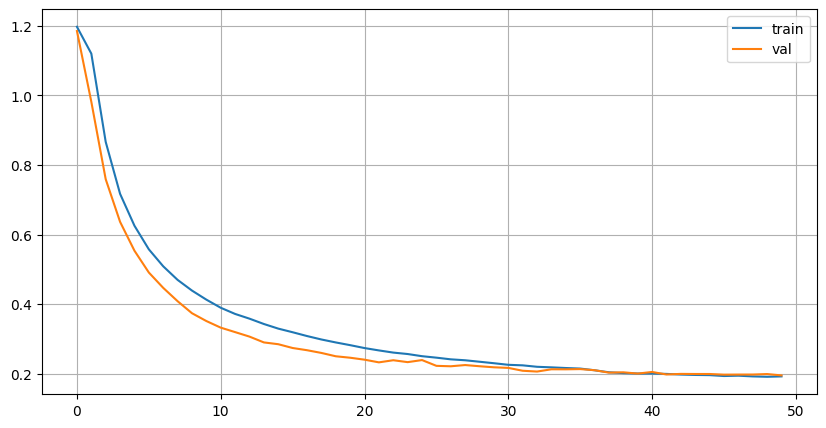

🏁 Training done.


In [ ]:
# =========================================
# Diffusion Teacher (T=30) + ESM-2 + CE_tok + Contrastive + TransformerDecoder
# Training + Validation + Inference (sample)
# =========================================

import torch, gc, glob, math
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import esm
import matplotlib.pyplot as plt

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧩 Device:", device)

# ---------------- Settings ----------------
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
PAD_IDX = len(AA_LIST)
vocab_size = len(AA_LIST) + 1
token_dim = 320
prot_dim = 320
T = 30
batch_size = 8
accum_steps = 1
epochs = 50
lr = 1e-4
patience = 12
pretrain_path = "/content/drive/MyDrive/Untitled folder/best_decoder_pretrain.pt"
teacher_path = "/content/drive/MyDrive/Untitled folder/best_teacher_diffusion.pt"

λ_diff, λ_ce, λ_con = 1.0, 0.05, 0.1

# ---------------- Load ESM-2 ----------------
esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.eval().to(device)
for param in esm_model.parameters():
    param.requires_grad = False
batch_converter = alphabet.get_batch_converter()
esm_proj = nn.Linear(esm_model.embed_dim, token_dim).to(device)

# ---------------- Cosine beta schedule ----------------
def cosine_beta_schedule(T, s=0.008):
    steps = T + 1
    t = torch.linspace(0, T, steps) / T
    alphas_cumprod = torch.cos((t + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 1e-4, 0.9999)

# ---------------- Dataset ----------------
class BatchEmbeddingDataset(Dataset):
    def __init__(self, prot_files, pep_emb_files, pep_token_files):
        self.prot_batches = [torch.load(f, map_location='cpu') for f in prot_files]
        self.pep_emb_batches = [torch.load(f, map_location='cpu') for f in pep_emb_files]
        self.pep_token_batches = [torch.load(f, map_location='cpu') for f in pep_token_files]
        self.lengths = [len(t) for t in self.pep_token_batches]
        self.cum_lengths = torch.cumsum(torch.tensor(self.lengths), dim=0)
        print(f"📦 Loaded {len(self.pep_token_batches)} files → total samples: {int(self.cum_lengths[-1])}")

    def __len__(self):
        return int(self.cum_lengths[-1])

    def __getitem__(self, idx):
        file_idx = int((self.cum_lengths > idx).nonzero()[0])
        inner_idx = idx if file_idx == 0 else idx - int(self.cum_lengths[file_idx-1])
        prot = self.prot_batches[file_idx][inner_idx].float()
        pep_emb = self.pep_emb_batches[file_idx][inner_idx].float()
        pep_tokens = self.pep_token_batches[file_idx][inner_idx].long()
        return prot, pep_emb, pep_tokens

def collate_fn(batch):
    prots, pep_embs, pep_tokens = zip(*batch)
    B = len(prots)

    Lpep = max(e.shape[0] for e in pep_embs)
    De = pep_embs[0].shape[1]
    pep_emb_pad = torch.zeros(B, Lpep, De, device=device)
    for i,e in enumerate(pep_embs):
        pep_emb_pad[i,:e.shape[0],:] = e.to(device)

    Lp = max(p.shape[0] for p in prots)
    Dp = prots[0].shape[1]
    prot_pad = torch.zeros(B, Lp, Dp, device=device)
    for i,p in enumerate(prots):
        prot_pad[i,:p.shape[0],:] = p.to(device)

    Ltok = max(len(t) for t in pep_tokens)
    pep_token_pad = torch.full((B,Ltok), PAD_IDX, dtype=torch.long, device=device)
    for i,t in enumerate(pep_tokens):
        pep_token_pad[i,:len(t)] = t.to(device)

    return prot_pad, pep_emb_pad, pep_token_pad

# ---------------- Load dataset ----------------
train_prot_files = sorted(glob.glob("/content/drive/MyDrive/Untitled folder/embedding/train_prot_emb_*.pt"))
train_pep_emb_files = sorted(glob.glob("/content/drive/MyDrive/Untitled folder/embedding/train_pep_emb_*.pt"))
train_pep_token_files = sorted(glob.glob("/content/drive/MyDrive/Untitled folder/embedding/train_pep_token_*.pt"))

val_prot_files   = sorted(glob.glob("/content/drive/MyDrive/Untitled folder/embedding/test_prot_emb_*.pt"))
val_pep_emb_files = sorted(glob.glob("/content/drive/MyDrive/Untitled folder/embedding/test_pep_emb_*.pt"))
val_pep_token_files = sorted(glob.glob("/content/drive/MyDrive/Untitled folder/embedding/test_pep_token_*.pt"))


train_dataset = BatchEmbeddingDataset(train_prot_files, train_pep_emb_files, train_pep_token_files)
val_dataset   = BatchEmbeddingDataset(val_prot_files, val_pep_emb_files, val_pep_token_files)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# ---------------- Time Embedding ----------------
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim, T):
        super().__init__()
        inv_freq = 1. / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)
        self.learnable = nn.Embedding(T, dim)
    def forward(self, t):
        t = t.float()
        sinusoid = torch.cat([torch.sin(t[:,None]*self.inv_freq[None,:]),
                              torch.cos(t[:,None]*self.inv_freq[None,:])], dim=-1)
        return sinusoid + self.learnable(t.long())

# ---------------- Transformer Denoiser ----------------
class TransformerDenoiser(nn.Module):
    def __init__(self, token_dim, prot_dim, nhead=4, nlayer=3, dropout=0.1):
        super().__init__()
        self.time_emb = SinusoidalTimeEmbedding(token_dim, T)
        encoder_layer = nn.TransformerEncoderLayer(d_model=token_dim, nhead=nhead, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=nlayer)
        self.out = nn.Linear(token_dim, token_dim)
        self.gamma_proj = nn.Linear(prot_dim, token_dim)
        self.beta_proj = nn.Linear(prot_dim, token_dim)
        self.layer_norm = nn.LayerNorm(token_dim)
        self.log_var_pep = nn.Linear(prot_dim, token_dim)
    def forward(self, xt, t, prot_emb):
        B,L,D = xt.shape
        prot_mean = prot_emb.mean(1)
        gamma = self.gamma_proj(prot_mean).unsqueeze(1)
        beta  = self.beta_proj(prot_mean).unsqueeze(1)
        xt_mod = gamma*xt + beta
        xt_mod = self.layer_norm(xt_mod)
        noise_pep = torch.randn_like(xt_mod)*torch.exp(0.5*self.log_var_pep(prot_mean)).unsqueeze(1)
        xt_mod = xt_mod + noise_pep
        t_emb = self.time_emb(t).unsqueeze(1).expand(B,L,D)
        out = self.out(self.encoder(xt_mod+t_emb))
        return out

# ---------------- Transformer Decoder (Pretrained) ----------------
class TransformerDecoder(nn.Module):
    def __init__(self, token_dim, vocab_size, nhead=8, nlayer=4, max_len=512, dropout=0.1):
        super().__init__()
        self.token_dim = token_dim
        self.pos_emb = nn.Parameter(torch.randn(1, max_len, token_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=token_dim,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayer)
        self.out = nn.Linear(token_dim, vocab_size)

    def forward(self, x):
        B,L,D = x.shape
        x = x + self.pos_emb[:, :L, :]
        x = self.transformer(x)
        logits = self.out(x)
        return logits

# ---------------- Diffusion Teacher ----------------
class DiffusionTeacher(nn.Module):
    def __init__(self, vocab_size, token_dim, prot_dim, T):
        super().__init__()
        self.decoder = TransformerDecoder(token_dim, vocab_size).to(device)  # ← نام attribute تغییر کرد
        self.denoiser = TransformerDenoiser(token_dim, prot_dim)
        betas = cosine_beta_schedule(T)
        alphas = 1. - betas
        alphas_bar = torch.cumprod(alphas, dim=0)
        self.register_buffer('betas', betas.to(device))
        self.register_buffer('alphas', alphas.to(device))
        self.register_buffer('alphas_bar', alphas_bar.to(device))
        self.T = T

    def q_sample(self, x0_emb, t):
        B,L,D = x0_emb.shape
        a_bar = self.alphas_bar[t].view(B,1,1)
        noise = torch.randn_like(x0_emb)
        xt = torch.sqrt(a_bar)*x0_emb + torch.sqrt(1.-a_bar)*noise
        return xt, noise

    def predict_noise(self, xt, t, prot_emb):
        return self.denoiser(xt, t, prot_emb)

    @torch.no_grad()
    def sample(self, prot_emb, L, return_logits=False):
        device_ = prot_emb.device
        xt = torch.randn(1, L, token_dim, device=device_)
        for t in reversed(range(1, self.T)):
            eps = self.predict_noise(xt, torch.tensor([t], device=device_), prot_emb)
            a = self.alphas[t]
            ab = self.alphas_bar[t]
            xt = (1/torch.sqrt(a))*(xt - ((1-a)/torch.sqrt(1-ab))*eps)
        logits = self.decoder(xt)  # ← تغییر نام
        tokens = logits.argmax(-1)
        if return_logits:
            return tokens, logits
        return tokens

# ---------------- Load Pretrained TransformerDecoder ----------------
pretrain_ckpt = torch.load(pretrain_path, map_location=device)
teacher = DiffusionTeacher(vocab_size, token_dim, prot_dim, T).to(device)
teacher.decoder.load_state_dict(pretrain_ckpt["decoder"])  # ← تغییر نام
esm_proj.load_state_dict(pretrain_ckpt["esm_proj"])
print("✅ Pretrained TransformerDecoder loaded into teacher!")

# ---------------- Helper functions ----------------
def tokens_to_seqs(token_matrix):
    seqs = []
    token_matrix = token_matrix.cpu().numpy()
    for row in token_matrix:
        s = []
        for idx in row:
            if idx < len(AA_LIST): s.append(AA_LIST[int(idx)])
            else: break
        seqs.append("".join(s))
    return seqs

def esm_embed_seqs(seq_list):
    labels = [str(i) for i in range(len(seq_list))]
    batch = list(zip(labels, seq_list))
    _,_,batch_tokens = batch_converter(batch)
    batch_tokens = batch_tokens.to(device)
    with torch.no_grad():
        out = esm_model(batch_tokens, repr_layers=[6])
        rep = out["representations"][6].mean(1)
    return esm_proj(rep)

# ---------------- Optimizer & Scheduler ----------------
opt = torch.optim.AdamW(
    list(teacher.parameters()) + list(esm_proj.parameters()),
    lr=lr,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)

# ---------------- Training loop ----------------
best_val = float('inf')
epochs_no_improve = 0
train_losses, val_losses = [], []

for epoch in range(1, epochs+1):
    teacher.train()
    tr_total=tr_diff=tr_ce=tr_con=0.0
    pbar = tqdm(train_loader, desc=f"🌀 Epoch {epoch} [Train]", leave=False)

    for step,(prot_pad,pep_emb_pad,pep_token_pad) in enumerate(pbar):
        B = prot_pad.size(0)
        Ltok = pep_token_pad.size(1)

        pooled = pep_emb_pad.mean(1)
        target_emb_proj = esm_proj(pooled.to(device)).detach()
        x0_single = target_emb_proj
        x0_emb = x0_single.unsqueeze(1).expand(B,Ltok,token_dim).to(device)
        prot_pad = prot_pad.to(device)
        pep_token_pad = pep_token_pad.to(device)

        t = torch.randint(1,teacher.T,(B,),device=device)
        xt, noise = teacher.q_sample(x0_emb,t)
        eps_pred = teacher.predict_noise(xt,t,prot_pad)
        loss_diff = F.mse_loss(eps_pred, noise)

        a_bar = teacher.alphas_bar[t].view(B,1,1)
        x0_pred = (xt - torch.sqrt(1.-a_bar)*eps_pred)/(torch.sqrt(a_bar)+1e-8)
        logits = teacher.decoder(x0_pred)  # ← تغییر نام

        loss_ce_token = F.cross_entropy(
            logits.view(-1,logits.size(-1)),
            pep_token_pad.view(-1),
            ignore_index=PAD_IDX
        )

        pred_tokens = torch.argmax(logits, dim=-1)
        pred_seqs = tokens_to_seqs(pred_tokens)

        with torch.no_grad():
            pred_emb = esm_embed_seqs(pred_seqs)

        pred_norm = F.normalize(pred_emb, dim=-1)
        target_norm = F.normalize(target_emb_proj, dim=-1)
        cos_sim = (pred_norm * target_norm).sum(dim=-1)
        loss_con = (1.0 - cos_sim).mean()

        total = λ_diff*loss_diff + λ_ce*loss_ce_token + λ_con*loss_con
        (total/accum_steps).backward()
        torch.nn.utils.clip_grad_norm_(teacher.parameters(), 1.0)

        if (step+1)%accum_steps==0:
            opt.step()
            opt.zero_grad()

        tr_total+=total.item()
        tr_diff+=loss_diff.item()
        tr_ce+=loss_ce_token.item()
        tr_con+=loss_con.item()

    # ---- Validation ----
    teacher.eval()
    val_total=val_diff=val_ce=val_con=0.0
    with torch.no_grad():
        for prot_pad,pep_emb_pad,pep_token_pad in val_loader:
            B = prot_pad.size(0)
            Ltok = pep_token_pad.size(1)

            pooled = pep_emb_pad.mean(1)
            target_emb_proj = esm_proj(pooled.to(device)).detach()
            x0_single = target_emb_proj
            x0_emb = x0_single.unsqueeze(1).expand(B,Ltok,token_dim).to(device)
            prot_pad = prot_pad.to(device)
            pep_token_pad = pep_token_pad.to(device)

            t = torch.randint(1,teacher.T,(B,),device=device)
            xt, noise = teacher.q_sample(x0_emb,t)
            eps_pred = teacher.predict_noise(xt,t,prot_pad)
            loss_diff = F.mse_loss(eps_pred, noise)

            a_bar = teacher.alphas_bar[t].view(B,1,1)
            x0_pred = (xt - torch.sqrt(1.-a_bar)*eps_pred)/(torch.sqrt(a_bar)+1e-8)
            logits = teacher.decoder(x0_pred)  # ← تغییر نام

            loss_ce_token = F.cross_entropy(
                logits.view(-1,logits.size(-1)),
                pep_token_pad.view(-1),
                ignore_index=PAD_IDX
            )

            pred_tokens = torch.argmax(logits, dim=-1)
            pred_seqs = tokens_to_seqs(pred_tokens)
            pred_emb = esm_embed_seqs(pred_seqs)

            pred_norm = F.normalize(pred_emb, dim=-1)
            target_norm = F.normalize(target_emb_proj, dim=-1)
            cos_sim = (pred_norm * target_norm).sum(dim=-1)
            loss_con = (1.0 - cos_sim).mean()

            val_total += λ_diff*loss_diff.item() + λ_ce*loss_ce_token.item() + λ_con*loss_con.item()
            val_diff += loss_diff.item()
            val_ce += loss_ce_token.item()
            val_con += loss_con.item()

    scheduler.step(val_total)
    train_losses.append(tr_total/len(train_loader))
    val_losses.append(val_total/len(val_loader))

    print(f"\n📘 Epoch {epoch}/{epochs}")
    print(f"Train → Total={train_losses[-1]:.4f} | Diff={tr_diff/len(train_loader):.4f} | CE_tok={tr_ce/len(train_loader):.4f} | Con={tr_con/len(train_loader):.4f}")
    print(f"Valid → Total={val_losses[-1]:.4f} | Diff={val_diff/len(val_loader):.4f} | CE_tok={val_ce/len(val_loader):.4f} | Con={val_con/len(val_loader):.4f}")

    if val_total < best_val:
        best_val = val_total
        epochs_no_improve = 0
        torch.save(teacher.state_dict(), teacher_path)
        print("✅ Best model saved!")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement for {epochs_no_improve} epochs")

    if epochs_no_improve >= patience:
        print("⏹️ Early stopping triggered.")
        break

    gc.collect()
    torch.cuda.empty_cache()

# ---------------- Plot training ----------------
plt.figure(figsize=(10,5))
plt.plot(train_losses,label='train')
plt.plot(val_losses,label='val')
plt.legend(); plt.grid(True)
plt.show()
print("🏁 Training done.")

# ---------------- Example inference ----------------
# prot_seq = ["YOUR_PROTEIN_SEQUENCE"]
# prot_emb = esm_embed_seqs(prot_seq)
# tokens = teacher.sample(prot_emb, L=desired_peptide_length)
# seq = tokens_to_seqs(tokens)
# print(seq)


In [ ]:
# ============================================
# single_protein_peptide_generation_verbose_first_only.py
# Generate multiple peptides for a single protein using Diffusion Teacher
# Uses ESM2 embeddings to score peptides
# Verbose debug prints only for first peptide
# ============================================

import os, math, torch, torch.nn as nn, torch.nn.functional as F
from collections import Counter
import esm
import pandas as pd

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧩 [Debug] Device:", device)

# ---------------- Settings ----------------
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
PAD_IDX = len(AA_LIST)
vocab_size = len(AA_LIST)+1

token_dim = 320
prot_dim = 320
T = 30
TEMPERATURE = 1.0
TOP_K = 10
TOP_P = 0.95
N_SAMPLES = 30
ALPHA, BETA, GAMMA = 0.7, 0.3, 0.5
print(f"⚙️ [Debug] Settings: N_SAMPLES={N_SAMPLES}, Temperature={TEMPERATURE}, TopK={TOP_K}, TopP={TOP_P}")

# ---------------- Paths ----------------
TEACHER_MODEL_PATH = "/content/drive/MyDrive/Untitled folder/best_teacher_diffusion.pt"
PRETRAIN_PATH      = "/content/drive/MyDrive/Untitled folder/best_decoder_pretrain.pt"

# ---------------- Helper Functions ----------------
def tokens_to_seqs(token_matrix, verbose=False):
    if torch.is_tensor(token_matrix):
        token_matrix = token_matrix.cpu().numpy()
    if token_matrix.ndim == 1:
        token_matrix = token_matrix[None,:]
    seqs = []
    for row in token_matrix:
        s = [AA_LIST[int(idx)] for idx in row if int(idx)<len(AA_LIST)]
        seqs.append("".join(s))
    if verbose:
        print(f"🔹 [Debug] tokens_to_seqs: {seqs}")
    return seqs[0] if len(seqs)==1 else seqs

def top_p_sampling(probs, top_p=0.95, verbose=False):
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cum_probs = torch.cumsum(sorted_probs, dim=-1)
    mask = cum_probs > top_p
    sorted_probs[mask] = 0
    if sorted_probs.sum() == 0:
        sorted_probs = torch.ones_like(sorted_probs)
    sorted_probs /= sorted_probs.sum()
    idx = torch.multinomial(sorted_probs, 1).item()
    if verbose:
        print(f"🔹 [Debug] top_p_sampling selected idx={sorted_idx[idx].item()}")
    return sorted_idx[idx].item()

def cosine_beta_schedule(T, s=0.008):
    steps = T+1
    t = torch.linspace(0,T,steps)/T
    alphas_cumprod = torch.cos((t+s)/(1+s)*math.pi*0.5)**2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1-(alphas_cumprod[1:]/alphas_cumprod[:-1])
    return torch.clip(betas,1e-4,0.9999)

def aa_distribution_score(seq, target_distribution, verbose=False):
    counter = Counter(seq)
    total = len(seq) if len(seq)>0 else 1
    score = 0.0
    for aa in AA_LIST:
        p_seq = counter.get(aa,0)/total
        p_target = target_distribution.get(aa,0)
        score += abs(p_seq - p_target)
    if verbose:
        print(f"🔹 [Debug] aa_distribution_score: {score}")
    return 1.0 - score

# ---------------- Models ----------------
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim, T):
        super().__init__()
        inv_freq = 1./(10000**(torch.arange(0,dim,2).float()/dim))
        self.register_buffer('inv_freq',inv_freq)
        self.learnable = nn.Embedding(T, dim)
        print("⏱️ [Debug] SinusoidalTimeEmbedding initialized")
    def forward(self, t):
        t = t.float()
        sinusoid = torch.cat([torch.sin(t[:,None]*self.inv_freq[None,:]),
                              torch.cos(t[:,None]*self.inv_freq[None,:])], dim=-1)
        return sinusoid + self.learnable(t.long())

class TransformerDenoiser(nn.Module):
    def __init__(self, token_dim, prot_dim, nhead=4, nlayer=3, dropout=0.1):
        super().__init__()
        print("🌀 [Debug] TransformerDenoiser initialized")
        self.time_emb = SinusoidalTimeEmbedding(token_dim, T)
        enc = nn.TransformerEncoderLayer(d_model=token_dim, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, nlayer)
        self.out = nn.Linear(token_dim, token_dim)
        self.gamma_proj = nn.Linear(prot_dim, token_dim)
        self.beta_proj  = nn.Linear(prot_dim, token_dim)
        self.layer_norm = nn.LayerNorm(token_dim)
        self.log_var_pep = nn.Linear(prot_dim, token_dim)
    def forward(self, xt, t, prot_emb, verbose=False):
        B,L,D = xt.shape
        prot_mean = prot_emb.mean(1) if prot_emb.dim()==3 else prot_emb
        gamma = self.gamma_proj(prot_mean).unsqueeze(1)
        beta  = self.beta_proj(prot_mean).unsqueeze(1)
        xt_mod = self.layer_norm(gamma*xt + beta)
        noise_pep = torch.randn_like(xt_mod)*torch.exp(0.5*self.log_var_pep(prot_mean)).unsqueeze(1)
        t_emb = self.time_emb(t).unsqueeze(1).expand(B,L,D)
        out = self.out(self.encoder(xt_mod + t_emb + noise_pep))
        if verbose:
            print(f"🔹 [Debug] TransformerDenoiser forward: out.shape={out.shape}")
        return out

class TransformerDecoder(nn.Module):
    def __init__(self, token_dim, vocab_size, nhead=8, nlayer=4, max_len=512):
        super().__init__()
        self.pos_emb = nn.Parameter(torch.randn(1, max_len, token_dim))
        enc = nn.TransformerEncoderLayer(d_model=token_dim,nhead=nhead,batch_first=True)
        self.transformer = nn.TransformerEncoder(enc,nlayer)
        self.out = nn.Linear(token_dim,vocab_size)
        print("📝 [Debug] TransformerDecoder initialized")
    def forward(self,x):
        B,L,D = x.shape
        x = x + self.pos_emb[:, :L, :]
        x = self.transformer(x)
        return self.out(x)

class DiffusionTeacher(nn.Module):
    def __init__(self, vocab_size, token_dim, prot_dim, T):
        super().__init__()
        print("🧑‍🏫 [Debug] DiffusionTeacher initialized")
        self.decoder = TransformerDecoder(token_dim, vocab_size)
        self.denoiser = TransformerDenoiser(token_dim, prot_dim)
        betas = cosine_beta_schedule(T)
        alphas = 1.-betas
        alphas_bar = torch.cumprod(alphas,dim=0)
        self.register_buffer('betas',betas.to(device))
        self.register_buffer('alphas',alphas.to(device))
        self.register_buffer('alphas_bar',alphas_bar.to(device))
        self.T = T
    def predict_noise(self,xt,t,prot_emb, verbose=False):
        if verbose:
            print(f"🔹 [Debug] DiffusionTeacher predict_noise called")
        return self.denoiser(xt,t,prot_emb, verbose=verbose)
    @torch.no_grad()
    def sample(self, prot_emb, L, temperature=1.0, topk=10, topp=0.95, verbose=False):
        if verbose:
            print(f"🔹 [Debug] Sampling started: L={L}")
        x = torch.randn(1,L,token_dim,device=device)
        for t in reversed(range(1,self.T)):
            t_tensor = torch.tensor([t],device=device)
            eps = self.predict_noise(x,t_tensor,prot_emb, verbose=verbose)
            a = self.alphas[t]
            ab = self.alphas_bar[t]
            x = (1/torch.sqrt(a))*(x - ((1-a)/torch.sqrt(1-ab))*eps)
        logits = self.decoder(x)/temperature
        tokens = []
        for i in range(L):
            token_probs = F.softmax(logits[0,i],dim=-1)
            topk_probs, topk_idx = torch.topk(token_probs, min(topk, token_probs.size(0)))
            topk_probs = topk_probs / (topk_probs.sum()+1e-12)
            idx = top_p_sampling(topk_probs, topp, verbose=verbose)
            tokens.append(topk_idx[idx].item())
        if verbose:
            print(f"🔹 [Debug] Sampling finished: tokens={tokens}")
        return torch.tensor(tokens, device=device), logits

# ---------------- Load Teacher & Pretrained Decoder ----------------
teacher = DiffusionTeacher(vocab_size, token_dim, prot_dim, T).to(device)
teacher.load_state_dict(torch.load(TEACHER_MODEL_PATH,map_location=device))
teacher.eval()
print("✅ [Debug] Teacher loaded")

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.eval().to(device)
batch_converter = alphabet.get_batch_converter()
esm_proj = nn.Linear(esm_model.embed_dim, token_dim).to(device)
if os.path.exists(PRETRAIN_PATH):
    pretrain = torch.load(PRETRAIN_PATH,map_location=device)
    esm_proj.load_state_dict(pretrain["esm_proj"])
print("✅ [Debug] ESM loaded")

@torch.no_grad()
def esm_embed_seq(seq, verbose=False):
    batch = [("seq",seq)]
    _,_,tokens = batch_converter(batch)
    tokens = tokens.to(device)
    out = esm_model(tokens,repr_layers=[6])
    rep = out["representations"][6].mean(1)
    if verbose:
        print(f"🔹 [Debug] esm_embed_seq computed embedding for seq={seq}")
    return esm_proj(rep)

@torch.no_grad()
def embed_protein(seq, verbose=False):
    batch = [("seq",seq)]
    _,_,tokens = batch_converter(batch)
    tokens = tokens.to(device)
    out = esm_model(tokens, repr_layers=[6])
    rep = out["representations"][6].mean(1)
    rep = esm_proj(rep)
    if verbose:
        print(f"🔹 [Debug] embed_protein computed embedding for protein length={len(seq)}")
    return rep

# ---------------- Single Protein Input ----------------
# Note: only the protein sequence is used as input for Diffusion conditions
protein_seq = "AWKGEVLANNEAGQVTSIIYNPGDVITIVAAGWASYGPTQKWGPQGDREHPDQGLICHDAFCGALVMKIGNSGTIPVNTGLFRWVAPNNVQGAITLIYNDVPGTYGNNSGSFSVNIGKDQSXXX"
target_pep_seq = "KPLX"  # Only used for final evaluation, not input to diffusion
L = len(target_pep_seq)
print(f"⚙️ [Debug] Protein length={len(protein_seq)}, target peptide length={L}")

aa_counter = Counter(target_pep_seq)
total_aa = sum(aa_counter.values()) if aa_counter else 1
aa_dist = {aa: aa_counter.get(aa,0)/total_aa for aa in AA_LIST}
print(f"🔹 [Debug] AA distribution for target peptide: {aa_dist}")

prot_emb = embed_protein(protein_seq, verbose=True)
target_emb = esm_embed_seq(target_pep_seq, verbose=True)

# ---------------- Generate Peptides ----------------
results = []
for s in range(N_SAMPLES):
    verbose = (s == 0)  # Only verbose for first sample
    if verbose:
        print(f"\n🧪 [Sample {s+1}/{N_SAMPLES}] Generating peptide...")
    tokens, logits = teacher.sample(prot_emb, L, temperature=TEMPERATURE, topk=TOP_K, topp=TOP_P, verbose=verbose)
    seq = tokens_to_seqs(tokens, verbose=verbose)

    # Only for evaluation: contrastive similarity with target peptide
    try:
        gen_emb = esm_embed_seq(seq, verbose=verbose)
        contrastive_score = F.cosine_similarity(F.normalize(gen_emb,dim=-1),
                                               F.normalize(target_emb,dim=-1),dim=-1).item()
    except Exception as e:
        if verbose:
            print(f"⚠️ [Debug] Contrastive score exception: {e}")
        contrastive_score = 0.0
    if verbose:
        print(f"🔹 [Debug] Contrastive score={contrastive_score:.4f}")

    # PPL score
    target_ids = [AA_LIST.index(a) if a in AA_LIST else PAD_IDX for a in seq]
    if len(target_ids) < logits.shape[1]:
        target_ids += [PAD_IDX]*(logits.shape[1]-len(target_ids))
    target_ids = torch.tensor(target_ids, device=device)
    ce_final = F.cross_entropy(logits.view(-1, logits.size(-1)), target_ids.view(-1), ignore_index=PAD_IDX, reduction='mean')
    ppl_final = math.exp(ce_final.item())
    if verbose:
        print(f"🔹 [Debug] PPL final={ppl_final:.4f}")

    # Baseline unigram PPL
    eps_prob = 1e-9
    log_probs = [math.log(max(aa_dist.get(a, eps_prob), eps_prob)) for a in seq]
    baseline_ce = -sum(log_probs)/len(log_probs) if log_probs else -math.log(eps_prob)
    baseline_ppl = math.exp(baseline_ce)
    ppl_normalized = ppl_final / (baseline_ppl+1e-12)
    if verbose:
        print(f"🔹 [Debug] PPL normalized={ppl_normalized:.4f}")

    # AA distribution score
    aa_score = aa_distribution_score(seq, aa_dist, verbose=verbose)

    # Hybrid final score
    final_score = ALPHA*contrastive_score + BETA*(1 - min(ppl_normalized/10,1.0)) + GAMMA*aa_score
    if verbose:
        print(f"🔹 [Debug] Final score={final_score:.4f}")

    results.append({
        "Generated Peptide": seq,
        "Contrastive Score": contrastive_score,
        "PPL Final": ppl_final,
        "PPL Normalized": ppl_normalized,
        "AA Balance": aa_score,
        "Final Score": final_score
    })

# ---------------- Sort and Save Results ----------------
results.sort(key=lambda x: x["Final Score"], reverse=True)
for rank, sample in enumerate(results[:10], start=1):
    print(f"🏆 Rank {rank}: {sample['Generated Peptide']} | Final Score: {sample['Final Score']:.4f}")

df_out = pd.DataFrame(results)
df_out.to_csv("/content/drive/MyDrive/new2/single_protein_generated_peptides_verbose_first_only.csv", index=False)
print("✅ [Debug] Saved all generated peptides to CSV")

🧩 [Debug] Device: cpu
⚙️ [Debug] Settings: N_SAMPLES=30, Temperature=1.0, TopK=10, TopP=0.95
🧑‍🏫 [Debug] DiffusionTeacher initialized
📝 [Debug] TransformerDecoder initialized
🌀 [Debug] TransformerDenoiser initialized
⏱️ [Debug] SinusoidalTimeEmbedding initialized
✅ [Debug] Teacher loaded
✅ [Debug] ESM loaded
⚙️ [Debug] Protein length=124, target peptide length=4
🔹 [Debug] AA distribution for target peptide: {'A': 0.0, 'C': 0.0, 'D': 0.0, 'E': 0.0, 'F': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'K': 0.25, 'L': 0.25, 'M': 0.0, 'N': 0.0, 'P': 0.25, 'Q': 0.0, 'R': 0.0, 'S': 0.0, 'T': 0.0, 'V': 0.0, 'W': 0.0, 'Y': 0.0}
🔹 [Debug] embed_protein computed embedding for protein length=124
🔹 [Debug] esm_embed_seq computed embedding for seq=KPLX

🧪 [Sample 1/30] Generating peptide...
🔹 [Debug] Sampling started: L=4
🔹 [Debug] DiffusionTeacher predict_noise called
🔹 [Debug] TransformerDenoiser forward: out.shape=torch.Size([1, 4, 320])
🔹 [Debug] DiffusionTeacher predict_noise called
🔹 [Debug] TransformerDe

In [ ]:
# ============================================
# single_protein_peptide_generation_verbose_first_only.py
# Generate multiple peptides for a single protein using Diffusion Teacher
# Uses ESM2 embeddings to score peptides
# Verbose debug prints only for first peptide
# ============================================

import os, math, torch, torch.nn as nn, torch.nn.functional as F
from collections import Counter
import esm
import pandas as pd

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧩 [Debug] Device:", device)

# ---------------- Settings ----------------
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
PAD_IDX = len(AA_LIST)
vocab_size = len(AA_LIST)+1

token_dim = 320
prot_dim = 320
T = 30
TEMPERATURE = 1.0
TOP_K = 10
TOP_P = 0.95
N_SAMPLES = 30
ALPHA, BETA, GAMMA = 0.7, 0.3, 0.5
print(f"⚙️ [Debug] Settings: N_SAMPLES={N_SAMPLES}, Temperature={TEMPERATURE}, TopK={TOP_K}, TopP={TOP_P}")

# ---------------- Paths ----------------
TEACHER_MODEL_PATH = "/content/drive/MyDrive/Untitled folder/best_teacher_diffusion.pt"
PRETRAIN_PATH      = "/content/drive/MyDrive/Untitled folder/best_decoder_pretrain.pt"

# ---------------- Helper Functions ----------------
def tokens_to_seqs(token_matrix, verbose=False):
    if torch.is_tensor(token_matrix):
        token_matrix = token_matrix.cpu().numpy()
    if token_matrix.ndim == 1:
        token_matrix = token_matrix[None,:]
    seqs = []
    for row in token_matrix:
        s = [AA_LIST[int(idx)] for idx in row if int(idx)<len(AA_LIST)]
        seqs.append("".join(s))
    if verbose:
        print(f"🔹 [Debug] tokens_to_seqs: {seqs}")
    return seqs[0] if len(seqs)==1 else seqs

def top_p_sampling(probs, top_p=0.95, verbose=False):
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cum_probs = torch.cumsum(sorted_probs, dim=-1)
    mask = cum_probs > top_p
    sorted_probs[mask] = 0
    if sorted_probs.sum() == 0:
        sorted_probs = torch.ones_like(sorted_probs)
    sorted_probs /= sorted_probs.sum()
    idx = torch.multinomial(sorted_probs, 1).item()
    if verbose:
        print(f"🔹 [Debug] top_p_sampling selected idx={sorted_idx[idx].item()}")
    return sorted_idx[idx].item()

def cosine_beta_schedule(T, s=0.008):
    steps = T+1
    t = torch.linspace(0,T,steps)/T
    alphas_cumprod = torch.cos((t+s)/(1+s)*math.pi*0.5)**2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1-(alphas_cumprod[1:]/alphas_cumprod[:-1])
    return torch.clip(betas,1e-4,0.9999)

def aa_distribution_score(seq, target_distribution, verbose=False):
    counter = Counter(seq)
    total = len(seq) if len(seq)>0 else 1
    score = 0.0
    for aa in AA_LIST:
        p_seq = counter.get(aa,0)/total
        p_target = target_distribution.get(aa,0)
        score += abs(p_seq - p_target)
    if verbose:
        print(f"🔹 [Debug] aa_distribution_score: {score}")
    return 1.0 - score

# ---------------- Models ----------------
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim, T):
        super().__init__()
        inv_freq = 1./(10000**(torch.arange(0,dim,2).float()/dim))
        self.register_buffer('inv_freq',inv_freq)
        self.learnable = nn.Embedding(T, dim)
        print("⏱️ [Debug] SinusoidalTimeEmbedding initialized")
    def forward(self, t):
        t = t.float()
        sinusoid = torch.cat([torch.sin(t[:,None]*self.inv_freq[None,:]),
                              torch.cos(t[:,None]*self.inv_freq[None,:])], dim=-1)
        return sinusoid + self.learnable(t.long())

class TransformerDenoiser(nn.Module):
    def __init__(self, token_dim, prot_dim, nhead=4, nlayer=3, dropout=0.1):
        super().__init__()
        print("🌀 [Debug] TransformerDenoiser initialized")
        self.time_emb = SinusoidalTimeEmbedding(token_dim, T)
        enc = nn.TransformerEncoderLayer(d_model=token_dim, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, nlayer)
        self.out = nn.Linear(token_dim, token_dim)
        self.gamma_proj = nn.Linear(prot_dim, token_dim)
        self.beta_proj  = nn.Linear(prot_dim, token_dim)
        self.layer_norm = nn.LayerNorm(token_dim)
        self.log_var_pep = nn.Linear(prot_dim, token_dim)
    def forward(self, xt, t, prot_emb, verbose=False):
        B,L,D = xt.shape
        prot_mean = prot_emb.mean(1) if prot_emb.dim()==3 else prot_emb
        gamma = self.gamma_proj(prot_mean).unsqueeze(1)
        beta  = self.beta_proj(prot_mean).unsqueeze(1)
        xt_mod = self.layer_norm(gamma*xt + beta)
        noise_pep = torch.randn_like(xt_mod)*torch.exp(0.5*self.log_var_pep(prot_mean)).unsqueeze(1)
        t_emb = self.time_emb(t).unsqueeze(1).expand(B,L,D)
        out = self.out(self.encoder(xt_mod + t_emb + noise_pep))
        if verbose:
            print(f"🔹 [Debug] TransformerDenoiser forward: out.shape={out.shape}")
        return out

class TransformerDecoder(nn.Module):
    def __init__(self, token_dim, vocab_size, nhead=8, nlayer=4, max_len=512):
        super().__init__()
        self.pos_emb = nn.Parameter(torch.randn(1, max_len, token_dim))
        enc = nn.TransformerEncoderLayer(d_model=token_dim,nhead=nhead,batch_first=True)
        self.transformer = nn.TransformerEncoder(enc,nlayer)
        self.out = nn.Linear(token_dim,vocab_size)
        print("📝 [Debug] TransformerDecoder initialized")
    def forward(self,x):
        B,L,D = x.shape
        x = x + self.pos_emb[:, :L, :]
        x = self.transformer(x)
        return self.out(x)

class DiffusionTeacher(nn.Module):
    def __init__(self, vocab_size, token_dim, prot_dim, T):
        super().__init__()
        print("🧑‍🏫 [Debug] DiffusionTeacher initialized")
        self.decoder = TransformerDecoder(token_dim, vocab_size)
        self.denoiser = TransformerDenoiser(token_dim, prot_dim)
        betas = cosine_beta_schedule(T)
        alphas = 1.-betas
        alphas_bar = torch.cumprod(alphas,dim=0)
        self.register_buffer('betas',betas.to(device))
        self.register_buffer('alphas',alphas.to(device))
        self.register_buffer('alphas_bar',alphas_bar.to(device))
        self.T = T
    def predict_noise(self,xt,t,prot_emb, verbose=False):
        if verbose:
            print(f"🔹 [Debug] DiffusionTeacher predict_noise called")
        return self.denoiser(xt,t,prot_emb, verbose=verbose)
    @torch.no_grad()
    def sample(self, prot_emb, L, temperature=1.0, topk=10, topp=0.95, verbose=False):
        if verbose:
            print(f"🔹 [Debug] Sampling started: L={L}")
        x = torch.randn(1,L,token_dim,device=device)
        for t in reversed(range(1,self.T)):
            t_tensor = torch.tensor([t],device=device)
            eps = self.predict_noise(x,t_tensor,prot_emb, verbose=verbose)
            a = self.alphas[t]
            ab = self.alphas_bar[t]
            x = (1/torch.sqrt(a))*(x - ((1-a)/torch.sqrt(1-ab))*eps)
        logits = self.decoder(x)/temperature
        tokens = []
        for i in range(L):
            token_probs = F.softmax(logits[0,i],dim=-1)
            topk_probs, topk_idx = torch.topk(token_probs, min(topk, token_probs.size(0)))
            topk_probs = topk_probs / (topk_probs.sum()+1e-12)
            idx = top_p_sampling(topk_probs, topp, verbose=verbose)
            tokens.append(topk_idx[idx].item())
        if verbose:
            print(f"🔹 [Debug] Sampling finished: tokens={tokens}")
        return torch.tensor(tokens, device=device), logits

# ---------------- Load Teacher & Pretrained Decoder ----------------
teacher = DiffusionTeacher(vocab_size, token_dim, prot_dim, T).to(device)
teacher.load_state_dict(torch.load(TEACHER_MODEL_PATH,map_location=device))
teacher.eval()
print("✅ [Debug] Teacher loaded")

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.eval().to(device)
batch_converter = alphabet.get_batch_converter()
esm_proj = nn.Linear(esm_model.embed_dim, token_dim).to(device)
if os.path.exists(PRETRAIN_PATH):
    pretrain = torch.load(PRETRAIN_PATH,map_location=device)
    esm_proj.load_state_dict(pretrain["esm_proj"])
print("✅ [Debug] ESM loaded")

@torch.no_grad()
def esm_embed_seq(seq, verbose=False):
    batch = [("seq",seq)]
    _,_,tokens = batch_converter(batch)
    tokens = tokens.to(device)
    out = esm_model(tokens,repr_layers=[6])
    rep = out["representations"][6].mean(1)
    if verbose:
        print(f"🔹 [Debug] esm_embed_seq computed embedding for seq={seq}")
    return esm_proj(rep)

@torch.no_grad()
def embed_protein(seq, verbose=False):
    batch = [("seq",seq)]
    _,_,tokens = batch_converter(batch)
    tokens = tokens.to(device)
    out = esm_model(tokens, repr_layers=[6])
    rep = out["representations"][6].mean(1)
    rep = esm_proj(rep)
    if verbose:
        print(f"🔹 [Debug] embed_protein computed embedding for protein length={len(seq)}")
    return rep

# ---------------- Single Protein Input ----------------
# Note: only the protein sequence is used as input for Diffusion conditions
# ============================================================
# Target-aware Conditioning Evaluation
# Protein condition sensitivity experiment

# Target-aware Evaluation with Centered Cosine
# ============================================================


target_pep_seq = "RSYSPDITQ"

L = len(target_pep_seq)



# ---------------------------------
# Compute all embeddings first
# ---------------------------------

all_peptide_embeddings = []


target_emb = esm_embed_seq(
    target_pep_seq
).detach()



for protein_name, protein_seq in protein_panel.items():

    prot_emb = embed_protein(
        protein_seq
    )

    all_peptide_embeddings.append(
        target_emb.squeeze(0)
    )


embedding_center = torch.stack(
    all_peptide_embeddings
).mean(0)



# ============================================================
# Generate
# ============================================================


results=[]


for protein_name, protein_seq in protein_panel.items():


    print("Processing:",protein_name)


    prot_emb = embed_protein(
        protein_seq
    )


    for sample_id in range(N_SAMPLES):


        tokens, logits = teacher.sample(
            prot_emb,
            L,
            temperature=TEMPERATURE,
            topk=TOP_K,
            topp=TOP_P
        )


        peptide = tokens_to_seqs(tokens)



        pep_emb = esm_embed_seq(
            peptide
        )



        # -----------------------------------
        # 1. peptide-native cosine
        # -----------------------------------

        cosine_native = F.cosine_similarity(
            F.normalize(
                pep_emb,
                dim=-1
            ),
            F.normalize(
                target_emb,
                dim=-1
            )
        ).item()



        # -----------------------------------
        # 2. centered cosine
        # -----------------------------------

        pep_centered = (
            pep_emb.squeeze(0)
            -
            embedding_center
        )


        target_centered = (
            target_emb.squeeze(0)
            -
            embedding_center
        )


        centered_cosine = F.cosine_similarity(
            pep_centered.unsqueeze(0),
            target_centered.unsqueeze(0)
        ).item()



        # -----------------------------------
        # 3. protein-peptide cosine
        # -----------------------------------

        protein_peptide_cosine = F.cosine_similarity(
            F.normalize(prot_emb,dim=-1),
            F.normalize(pep_emb,dim=-1)
        ).item()



        results.append({

            "Protein":
            protein_name,

            "Sample":
            sample_id+1,

            "Generated_Peptide":
            peptide,

            "Native_Peptide":
            target_pep_seq,


            "Native_Cosine":
            cosine_native,


            "Centered_Cosine":
            centered_cosine,


            "Protein_Peptide_Cosine":
            protein_peptide_cosine

        })



df=pd.DataFrame(results)


save_path="/content/drive/MyDrive/new2/target_aware_centered_results.csv"


df.to_csv(
    save_path,
    index=False
)


print("Saved:",save_path)



summary=df.groupby("Protein").agg({

"Native_Cosine":"mean",

"Centered_Cosine":"mean",

"Protein_Peptide_Cosine":"mean"

})


print(summary)

🧩 [Debug] Device: cuda
⚙️ [Debug] Settings: N_SAMPLES=30, Temperature=1.0, TopK=10, TopP=0.95
🧑‍🏫 [Debug] DiffusionTeacher initialized
📝 [Debug] TransformerDecoder initialized
🌀 [Debug] TransformerDenoiser initialized
⏱️ [Debug] SinusoidalTimeEmbedding initialized
✅ [Debug] Teacher loaded
✅ [Debug] ESM loaded
Processing: Target
Processing: Decoy_1
Processing: Decoy_2
Processing: Decoy_3
Saved: /content/drive/MyDrive/new2/target_aware_centered_results.csv
         Native_Cosine  Centered_Cosine  Protein_Peptide_Cosine
Protein                                                        
Decoy_1       0.899286              0.0                0.599084
Decoy_2       0.916924              0.0                0.753609
Decoy_3       0.915652              0.0                0.823925
Target        0.892346              0.0                0.715648


In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.6 MB/s eta 0:00:00


In [ ]:
!pip install fair-esm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 8.1 MB/s eta 0:00:00


In [ ]:
# ============================================================
# Peptide Similarity Analysis
# Sequence Identity + ESM2 Cosine Similarity
# ============================================================

import torch
import torch.nn.functional as F
import pandas as pd
import esm


# -----------------------------
# Load ESM2
# -----------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)


esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()

esm_model = esm_model.to(device)
esm_model.eval()

batch_converter = alphabet.get_batch_converter()



# -----------------------------
# Peptides
# -----------------------------

target = "KPLX"

generated = [
    "KDLK",
    "PAKL"
]



# -----------------------------
# Sequence Identity
# -----------------------------

def sequence_identity(seq1, seq2):

    length = max(len(seq1), len(seq2))

    matches = sum(
        a == b
        for a, b in zip(seq1, seq2)
    )

    return (matches / length) * 100



# -----------------------------
# ESM2 embedding
# -----------------------------

@torch.no_grad()
def esm_embedding(sequence):

    batch = [
        ("pep", sequence)
    ]

    _, _, tokens = batch_converter(batch)

    tokens = tokens.to(device)


    output = esm_model(
        tokens,
        repr_layers=[6]
    )


    embedding = output["representations"][6][0,1:-1].mean(0)

    return embedding



# -----------------------------
# Target embedding
# -----------------------------

target_emb = esm_embedding(target)



# -----------------------------
# Compare
# -----------------------------

results = []


for pep in generated:

    identity = sequence_identity(
        target,
        pep
    )


    pep_emb = esm_embedding(pep)


    cosine = F.cosine_similarity(
        target_emb.unsqueeze(0),
        pep_emb.unsqueeze(0)
    ).item()


    results.append(
        {
            "Target": target,
            "Generated": pep,
            "Sequence_Identity_%": round(identity,2),
            "ESM2_Cosine": round(cosine,4)
        }
    )



df = pd.DataFrame(results)

print(df)


df.to_csv(
    "peptide_similarity_results.csv",
    index=False
)

Device: cuda
  Target Generated  Sequence_Identity_%  ESM2_Cosine
0   KPLX      KDLK                 50.0       0.9697
1   KPLX      PAKL                  0.0       0.9746


In [ ]:
# ============================================================
# Peptide Similarity Analysis
# Sequence Identity + ESM2 Cosine Similarity
# ============================================================

import torch
import torch.nn.functional as F
import pandas as pd
import esm


# ============================================================
# 1. Load ESM2 model
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)


# ESM2 8M
esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()


esm_model = esm_model.to(device)
esm_model.eval()


batch_converter = alphabet.get_batch_converter()



# ============================================================
# 2. Input peptides
# ============================================================

target = "KPLX"

generated_peptides = [
    "KDLK",
    "PAKL"
]



# ============================================================
# 3. Sequence Identity
# ============================================================

def sequence_identity(seq1, seq2):

    length = max(
        len(seq1),
        len(seq2)
    )

    matches = 0


    for a,b in zip(seq1,seq2):

        if a == b:
            matches += 1


    identity = matches / length


    return identity * 100




# ============================================================
# 4. ESM2 embedding function
# ============================================================

@torch.no_grad()
def esm_embedding(sequence):


    data = [
        ("peptide", sequence)
    ]


    _, _, tokens = batch_converter(data)


    tokens = tokens.to(device)



    output = esm_model(
        tokens,
        repr_layers=[6]
    )


    # token embeddings
    token_embedding = output["representations"][6]


    # remove BOS and EOS
    embedding = token_embedding[
        0,
        1:-1
    ].mean(dim=0)


    return embedding



# ============================================================
# 5. Target embedding
# ============================================================

target_embedding = esm_embedding(target)


print(
    "Embedding dimension:",
    target_embedding.shape
)



# ============================================================
# 6. Compare peptides
# ============================================================

results = []


for peptide in generated_peptides:


    # Sequence identity

    seq_id = sequence_identity(
        target,
        peptide
    )


    # Embedding

    peptide_embedding = esm_embedding(
        peptide
    )


    # Cosine similarity

    cosine_similarity = F.cosine_similarity(
        target_embedding.unsqueeze(0),
        peptide_embedding.unsqueeze(0)
    ).item()



    # Distance

    cosine_distance = 1 - cosine_similarity



    results.append({

        "Target": target,

        "Generated": peptide,

        "Length": len(peptide),

        "Sequence_Identity_%": round(
            seq_id,
            2
        ),

        "ESM2_Cosine_Similarity": round(
            cosine_similarity,
            4
        ),

        "ESM2_Cosine_Distance": round(
            cosine_distance,
            4
        )

    })



# ============================================================
# 7. Results table
# ============================================================

df = pd.DataFrame(results)


print("\nResults:")
display(df)



# ============================================================
# 8. Save
# ============================================================

output_file = "peptide_similarity_results.csv"


df.to_csv(
    output_file,
    index=False
)


print(
    "\nSaved:",
    output_file
)

Using device: cuda
Embedding dimension: torch.Size([320])

Results:


,Target,Generated,Length,Sequence_Identity_%,ESM2_Cosine_Similarity,ESM2_Cosine_Distance
0,KPLX,KDLK,4,50.0,0.9697,0.0303
1,KPLX,PAKL,4,0.0,0.9746,0.0254



Saved: peptide_similarity_results.csv


In [ ]:
# ============================================
# single_protein_peptide_generation_verbose_first_only.py
# Generate multiple peptides for a single protein using Diffusion Teacher
# Uses ESM2 embeddings to score peptides
# Verbose debug prints only for first peptide
# ============================================

import os, math, torch, torch.nn as nn, torch.nn.functional as F
from collections import Counter
import esm
import pandas as pd

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧩 [Debug] Device:", device)

# ---------------- Settings ----------------
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
PAD_IDX = len(AA_LIST)
vocab_size = len(AA_LIST)+1

token_dim = 320
prot_dim = 320
T = 30
TEMPERATURE = 1.0
TOP_K = 10
TOP_P = 0.95
N_SAMPLES = 30
ALPHA, BETA, GAMMA = 0.7, 0.3, 0.5
print(f"⚙️ [Debug] Settings: N_SAMPLES={N_SAMPLES}, Temperature={TEMPERATURE}, TopK={TOP_K}, TopP={TOP_P}")

# ---------------- Paths ----------------
TEACHER_MODEL_PATH = "/content/drive/MyDrive/Untitled folder/best_teacher_diffusion.pt"
PRETRAIN_PATH      = "/content/drive/MyDrive/Untitled folder/best_decoder_pretrain.pt"

# ---------------- Helper Functions ----------------
def tokens_to_seqs(token_matrix, verbose=False):
    if torch.is_tensor(token_matrix):
        token_matrix = token_matrix.cpu().numpy()
    if token_matrix.ndim == 1:
        token_matrix = token_matrix[None,:]
    seqs = []
    for row in token_matrix:
        s = [AA_LIST[int(idx)] for idx in row if int(idx)<len(AA_LIST)]
        seqs.append("".join(s))
    if verbose:
        print(f"🔹 [Debug] tokens_to_seqs: {seqs}")
    return seqs[0] if len(seqs)==1 else seqs

def top_p_sampling(probs, top_p=0.95, verbose=False):
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cum_probs = torch.cumsum(sorted_probs, dim=-1)
    mask = cum_probs > top_p
    sorted_probs[mask] = 0
    if sorted_probs.sum() == 0:
        sorted_probs = torch.ones_like(sorted_probs)
    sorted_probs /= sorted_probs.sum()
    idx = torch.multinomial(sorted_probs, 1).item()
    if verbose:
        print(f"🔹 [Debug] top_p_sampling selected idx={sorted_idx[idx].item()}")
    return sorted_idx[idx].item()

def cosine_beta_schedule(T, s=0.008):
    steps = T+1
    t = torch.linspace(0,T,steps)/T
    alphas_cumprod = torch.cos((t+s)/(1+s)*math.pi*0.5)**2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1-(alphas_cumprod[1:]/alphas_cumprod[:-1])
    return torch.clip(betas,1e-4,0.9999)

def aa_distribution_score(seq, target_distribution, verbose=False):
    counter = Counter(seq)
    total = len(seq) if len(seq)>0 else 1
    score = 0.0
    for aa in AA_LIST:
        p_seq = counter.get(aa,0)/total
        p_target = target_distribution.get(aa,0)
        score += abs(p_seq - p_target)
    if verbose:
        print(f"🔹 [Debug] aa_distribution_score: {score}")
    return 1.0 - score

# ---------------- Models ----------------
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim, T):
        super().__init__()
        inv_freq = 1./(10000**(torch.arange(0,dim,2).float()/dim))
        self.register_buffer('inv_freq',inv_freq)
        self.learnable = nn.Embedding(T, dim)
        print("⏱️ [Debug] SinusoidalTimeEmbedding initialized")
    def forward(self, t):
        t = t.float()
        sinusoid = torch.cat([torch.sin(t[:,None]*self.inv_freq[None,:]),
                              torch.cos(t[:,None]*self.inv_freq[None,:])], dim=-1)
        return sinusoid + self.learnable(t.long())

class TransformerDenoiser(nn.Module):
    def __init__(self, token_dim, prot_dim, nhead=4, nlayer=3, dropout=0.1):
        super().__init__()
        print("🌀 [Debug] TransformerDenoiser initialized")
        self.time_emb = SinusoidalTimeEmbedding(token_dim, T)
        enc = nn.TransformerEncoderLayer(d_model=token_dim, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, nlayer)
        self.out = nn.Linear(token_dim, token_dim)
        self.gamma_proj = nn.Linear(prot_dim, token_dim)
        self.beta_proj  = nn.Linear(prot_dim, token_dim)
        self.layer_norm = nn.LayerNorm(token_dim)
        self.log_var_pep = nn.Linear(prot_dim, token_dim)
    def forward(self, xt, t, prot_emb, verbose=False):
        B,L,D = xt.shape
        prot_mean = prot_emb.mean(1) if prot_emb.dim()==3 else prot_emb
        gamma = self.gamma_proj(prot_mean).unsqueeze(1)
        beta  = self.beta_proj(prot_mean).unsqueeze(1)
        xt_mod = self.layer_norm(gamma*xt + beta)
        noise_pep = torch.randn_like(xt_mod)*torch.exp(0.5*self.log_var_pep(prot_mean)).unsqueeze(1)
        t_emb = self.time_emb(t).unsqueeze(1).expand(B,L,D)
        out = self.out(self.encoder(xt_mod + t_emb + noise_pep))
        if verbose:
            print(f"🔹 [Debug] TransformerDenoiser forward: out.shape={out.shape}")
        return out

class TransformerDecoder(nn.Module):
    def __init__(self, token_dim, vocab_size, nhead=8, nlayer=4, max_len=512):
        super().__init__()
        self.pos_emb = nn.Parameter(torch.randn(1, max_len, token_dim))
        enc = nn.TransformerEncoderLayer(d_model=token_dim,nhead=nhead,batch_first=True)
        self.transformer = nn.TransformerEncoder(enc,nlayer)
        self.out = nn.Linear(token_dim,vocab_size)
        print("📝 [Debug] TransformerDecoder initialized")
    def forward(self,x):
        B,L,D = x.shape
        x = x + self.pos_emb[:, :L, :]
        x = self.transformer(x)
        return self.out(x)

class DiffusionTeacher(nn.Module):
    def __init__(self, vocab_size, token_dim, prot_dim, T):
        super().__init__()
        print("🧑‍🏫 [Debug] DiffusionTeacher initialized")
        self.decoder = TransformerDecoder(token_dim, vocab_size)
        self.denoiser = TransformerDenoiser(token_dim, prot_dim)
        betas = cosine_beta_schedule(T)
        alphas = 1.-betas
        alphas_bar = torch.cumprod(alphas,dim=0)
        self.register_buffer('betas',betas.to(device))
        self.register_buffer('alphas',alphas.to(device))
        self.register_buffer('alphas_bar',alphas_bar.to(device))
        self.T = T
    def predict_noise(self,xt,t,prot_emb, verbose=False):
        if verbose:
            print(f"🔹 [Debug] DiffusionTeacher predict_noise called")
        return self.denoiser(xt,t,prot_emb, verbose=verbose)
    @torch.no_grad()
    def sample(self, prot_emb, L, temperature=1.0, topk=10, topp=0.95, verbose=False):
        if verbose:
            print(f"🔹 [Debug] Sampling started: L={L}")
        x = torch.randn(1,L,token_dim,device=device)
        for t in reversed(range(1,self.T)):
            t_tensor = torch.tensor([t],device=device)
            eps = self.predict_noise(x,t_tensor,prot_emb, verbose=verbose)
            a = self.alphas[t]
            ab = self.alphas_bar[t]
            x = (1/torch.sqrt(a))*(x - ((1-a)/torch.sqrt(1-ab))*eps)
        logits = self.decoder(x)/temperature
        tokens = []
        for i in range(L):
            token_probs = F.softmax(logits[0,i],dim=-1)
            topk_probs, topk_idx = torch.topk(token_probs, min(topk, token_probs.size(0)))
            topk_probs = topk_probs / (topk_probs.sum()+1e-12)
            idx = top_p_sampling(topk_probs, topp, verbose=verbose)
            tokens.append(topk_idx[idx].item())
        if verbose:
            print(f"🔹 [Debug] Sampling finished: tokens={tokens}")
        return torch.tensor(tokens, device=device), logits

# ---------------- Load Teacher & Pretrained Decoder ----------------
teacher = DiffusionTeacher(vocab_size, token_dim, prot_dim, T).to(device)
teacher.load_state_dict(torch.load(TEACHER_MODEL_PATH,map_location=device))
teacher.eval()
print("✅ [Debug] Teacher loaded")

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.eval().to(device)
batch_converter = alphabet.get_batch_converter()
esm_proj = nn.Linear(esm_model.embed_dim, token_dim).to(device)
if os.path.exists(PRETRAIN_PATH):
    pretrain = torch.load(PRETRAIN_PATH,map_location=device)
    esm_proj.load_state_dict(pretrain["esm_proj"])
print("✅ [Debug] ESM loaded")

@torch.no_grad()
def esm_embed_seq(seq, verbose=False):
    batch = [("seq",seq)]
    _,_,tokens = batch_converter(batch)
    tokens = tokens.to(device)
    out = esm_model(tokens,repr_layers=[6])
    rep = out["representations"][6].mean(1)
    if verbose:
        print(f"🔹 [Debug] esm_embed_seq computed embedding for seq={seq}")
    return esm_proj(rep)

@torch.no_grad()
def embed_protein(seq, verbose=False):
    batch = [("seq",seq)]
    _,_,tokens = batch_converter(batch)
    tokens = tokens.to(device)
    out = esm_model(tokens, repr_layers=[6])
    rep = out["representations"][6].mean(1)
    rep = esm_proj(rep)
    if verbose:
        print(f"🔹 [Debug] embed_protein computed embedding for protein length={len(seq)}")
    return rep

# ---------------- Single Protein Input ----------------
# Note: only the protein sequence is used as input for Diffusion conditions
protein_seq = "AWKGEVLANNEAGQVTSIIYNPGDVITIVAAGWASYGPTQKWGPQGDREHPDQGLICHDAFCGALVMKIGNSGTIPVNTGLFRWVAPNNVQGAITLIYNDVPGTYGNNSGSFSVNIGKDQSXXX"
target_pep_seq = "KPLX"  # Only used for final evaluation, not input to diffusion
L = len(target_pep_seq)
print(f"⚙️ [Debug] Protein length={len(protein_seq)}, target peptide length={L}")

aa_counter = Counter(target_pep_seq)
total_aa = sum(aa_counter.values()) if aa_counter else 1
aa_dist = {aa: aa_counter.get(aa,0)/total_aa for aa in AA_LIST}
print(f"🔹 [Debug] AA distribution for target peptide: {aa_dist}")

prot_emb = embed_protein(protein_seq, verbose=True)
target_emb = esm_embed_seq(target_pep_seq, verbose=True)

# ---------------- Generate Peptides ----------------
results = []
for s in range(N_SAMPLES):
    verbose = (s == 0)  # Only verbose for first sample
    if verbose:
        print(f"\n🧪 [Sample {s+1}/{N_SAMPLES}] Generating peptide...")
    tokens, logits = teacher.sample(prot_emb, L, temperature=TEMPERATURE, topk=TOP_K, topp=TOP_P, verbose=verbose)
    seq = tokens_to_seqs(tokens, verbose=verbose)

    # Only for evaluation: contrastive similarity with target peptide
    try:
        gen_emb = esm_embed_seq(seq, verbose=verbose)
        contrastive_score = F.cosine_similarity(F.normalize(gen_emb,dim=-1),
                                               F.normalize(target_emb,dim=-1),dim=-1).item()
    except Exception as e:
        if verbose:
            print(f"⚠️ [Debug] Contrastive score exception: {e}")
        contrastive_score = 0.0
    if verbose:
        print(f"🔹 [Debug] Contrastive score={contrastive_score:.4f}")

    # PPL score
    target_ids = [AA_LIST.index(a) if a in AA_LIST else PAD_IDX for a in seq]
    if len(target_ids) < logits.shape[1]:
        target_ids += [PAD_IDX]*(logits.shape[1]-len(target_ids))
    target_ids = torch.tensor(target_ids, device=device)
    ce_final = F.cross_entropy(logits.view(-1, logits.size(-1)), target_ids.view(-1), ignore_index=PAD_IDX, reduction='mean')
    ppl_final = math.exp(ce_final.item())
    if verbose:
        print(f"🔹 [Debug] PPL final={ppl_final:.4f}")

    # Baseline unigram PPL
    eps_prob = 1e-9
    log_probs = [math.log(max(aa_dist.get(a, eps_prob), eps_prob)) for a in seq]
    baseline_ce = -sum(log_probs)/len(log_probs) if log_probs else -math.log(eps_prob)
    baseline_ppl = math.exp(baseline_ce)
    ppl_normalized = ppl_final / (baseline_ppl+1e-12)
    if verbose:
        print(f"🔹 [Debug] PPL normalized={ppl_normalized:.4f}")

    # AA distribution score
    aa_score = aa_distribution_score(seq, aa_dist, verbose=verbose)

    # Hybrid final score
    final_score = ALPHA*contrastive_score + BETA*(1 - min(ppl_normalized/10,1.0)) + GAMMA*aa_score
    if verbose:
        print(f"🔹 [Debug] Final score={final_score:.4f}")

    results.append({
        "Generated Peptide": seq,
        "Contrastive Score": contrastive_score,
        "PPL Final": ppl_final,
        "PPL Normalized": ppl_normalized,
        "AA Balance": aa_score,
        "Final Score": final_score
    })

# ---------------- Sort and Save Results ----------------
results.sort(key=lambda x: x["Final Score"], reverse=True)
for rank, sample in enumerate(results[:10], start=1):
    print(f"🏆 Rank {rank}: {sample['Generated Peptide']} | Final Score: {sample['Final Score']:.4f}")

df_out = pd.DataFrame(results)
df_out.to_csv("/content/drive/MyDrive/new2/single_protein_generated_peptides_verbose_first_only.csv", index=False)
print("✅ [Debug] Saved all generated peptides to CSV")

🧩 [Debug] Device: cpu
⚙️ [Debug] Settings: N_SAMPLES=30, Temperature=1.0, TopK=10, TopP=0.95
🧑‍🏫 [Debug] DiffusionTeacher initialized
📝 [Debug] TransformerDecoder initialized
🌀 [Debug] TransformerDenoiser initialized
⏱️ [Debug] SinusoidalTimeEmbedding initialized
✅ [Debug] Teacher loaded
✅ [Debug] ESM loaded
⚙️ [Debug] Protein length=124, target peptide length=4
🔹 [Debug] AA distribution for target peptide: {'A': 0.0, 'C': 0.0, 'D': 0.0, 'E': 0.0, 'F': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'K': 0.25, 'L': 0.25, 'M': 0.0, 'N': 0.0, 'P': 0.25, 'Q': 0.0, 'R': 0.0, 'S': 0.0, 'T': 0.0, 'V': 0.0, 'W': 0.0, 'Y': 0.0}
🔹 [Debug] embed_protein computed embedding for protein length=124
🔹 [Debug] esm_embed_seq computed embedding for seq=KPLX

🧪 [Sample 1/30] Generating peptide...
🔹 [Debug] Sampling started: L=4
🔹 [Debug] DiffusionTeacher predict_noise called
🔹 [Debug] TransformerDenoiser forward: out.shape=torch.Size([1, 4, 320])
🔹 [Debug] DiffusionTeacher predict_noise called
🔹 [Debug] TransformerDe

In [ ]:
# ============================================
# single_protein_peptide_generation_verbose_first_only.py
# Generate multiple peptides for a single protein using Diffusion Teacher
# Uses ESM2 embeddings to score peptides
# Verbose debug prints only for first peptide
# ============================================

import os, math, torch, torch.nn as nn, torch.nn.functional as F
from collections import Counter
import esm
import pandas as pd

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧩 [Debug] Device:", device)

# ---------------- Settings ----------------
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
PAD_IDX = len(AA_LIST)
vocab_size = len(AA_LIST)+1

token_dim = 320
prot_dim = 320
T = 30
TEMPERATURE = 1.0
TOP_K = 10
TOP_P = 0.95
N_SAMPLES = 30
ALPHA, BETA, GAMMA = 0.7, 0.3, 0.5
print(f"⚙️ [Debug] Settings: N_SAMPLES={N_SAMPLES}, Temperature={TEMPERATURE}, TopK={TOP_K}, TopP={TOP_P}")

# ---------------- Paths ----------------
TEACHER_MODEL_PATH = "/content/drive/MyDrive/Untitled folder/best_teacher_diffusion.pt"
PRETRAIN_PATH      = "/content/drive/MyDrive/Untitled folder/best_decoder_pretrain.pt"

# ---------------- Helper Functions ----------------
def tokens_to_seqs(token_matrix, verbose=False):
    if torch.is_tensor(token_matrix):
        token_matrix = token_matrix.cpu().numpy()
    if token_matrix.ndim == 1:
        token_matrix = token_matrix[None,:]
    seqs = []
    for row in token_matrix:
        s = [AA_LIST[int(idx)] for idx in row if int(idx)<len(AA_LIST)]
        seqs.append("".join(s))
    if verbose:
        print(f"🔹 [Debug] tokens_to_seqs: {seqs}")
    return seqs[0] if len(seqs)==1 else seqs

def top_p_sampling(probs, top_p=0.95, verbose=False):
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cum_probs = torch.cumsum(sorted_probs, dim=-1)
    mask = cum_probs > top_p
    sorted_probs[mask] = 0
    if sorted_probs.sum() == 0:
        sorted_probs = torch.ones_like(sorted_probs)
    sorted_probs /= sorted_probs.sum()
    idx = torch.multinomial(sorted_probs, 1).item()
    if verbose:
        print(f"🔹 [Debug] top_p_sampling selected idx={sorted_idx[idx].item()}")
    return sorted_idx[idx].item()

def cosine_beta_schedule(T, s=0.008):
    steps = T+1
    t = torch.linspace(0,T,steps)/T
    alphas_cumprod = torch.cos((t+s)/(1+s)*math.pi*0.5)**2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1-(alphas_cumprod[1:]/alphas_cumprod[:-1])
    return torch.clip(betas,1e-4,0.9999)

def aa_distribution_score(seq, target_distribution, verbose=False):
    counter = Counter(seq)
    total = len(seq) if len(seq)>0 else 1
    score = 0.0
    for aa in AA_LIST:
        p_seq = counter.get(aa,0)/total
        p_target = target_distribution.get(aa,0)
        score += abs(p_seq - p_target)
    if verbose:
        print(f"🔹 [Debug] aa_distribution_score: {score}")
    return 1.0 - score

# ---------------- Models ----------------
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim, T):
        super().__init__()
        inv_freq = 1./(10000**(torch.arange(0,dim,2).float()/dim))
        self.register_buffer('inv_freq',inv_freq)
        self.learnable = nn.Embedding(T, dim)
        print("⏱️ [Debug] SinusoidalTimeEmbedding initialized")
    def forward(self, t):
        t = t.float()
        sinusoid = torch.cat([torch.sin(t[:,None]*self.inv_freq[None,:]),
                              torch.cos(t[:,None]*self.inv_freq[None,:])], dim=-1)
        return sinusoid + self.learnable(t.long())

class TransformerDenoiser(nn.Module):
    def __init__(self, token_dim, prot_dim, nhead=4, nlayer=3, dropout=0.1):
        super().__init__()
        print("🌀 [Debug] TransformerDenoiser initialized")
        self.time_emb = SinusoidalTimeEmbedding(token_dim, T)
        enc = nn.TransformerEncoderLayer(d_model=token_dim, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, nlayer)
        self.out = nn.Linear(token_dim, token_dim)
        self.gamma_proj = nn.Linear(prot_dim, token_dim)
        self.beta_proj  = nn.Linear(prot_dim, token_dim)
        self.layer_norm = nn.LayerNorm(token_dim)
        self.log_var_pep = nn.Linear(prot_dim, token_dim)
    def forward(self, xt, t, prot_emb, verbose=False):
        B,L,D = xt.shape
        prot_mean = prot_emb.mean(1) if prot_emb.dim()==3 else prot_emb
        gamma = self.gamma_proj(prot_mean).unsqueeze(1)
        beta  = self.beta_proj(prot_mean).unsqueeze(1)
        xt_mod = self.layer_norm(gamma*xt + beta)
        noise_pep = torch.randn_like(xt_mod)*torch.exp(0.5*self.log_var_pep(prot_mean)).unsqueeze(1)
        t_emb = self.time_emb(t).unsqueeze(1).expand(B,L,D)
        out = self.out(self.encoder(xt_mod + t_emb + noise_pep))
        if verbose:
            print(f"🔹 [Debug] TransformerDenoiser forward: out.shape={out.shape}")
        return out

class TransformerDecoder(nn.Module):
    def __init__(self, token_dim, vocab_size, nhead=8, nlayer=4, max_len=512):
        super().__init__()
        self.pos_emb = nn.Parameter(torch.randn(1, max_len, token_dim))
        enc = nn.TransformerEncoderLayer(d_model=token_dim,nhead=nhead,batch_first=True)
        self.transformer = nn.TransformerEncoder(enc,nlayer)
        self.out = nn.Linear(token_dim,vocab_size)
        print("📝 [Debug] TransformerDecoder initialized")
    def forward(self,x):
        B,L,D = x.shape
        x = x + self.pos_emb[:, :L, :]
        x = self.transformer(x)
        return self.out(x)

class DiffusionTeacher(nn.Module):
    def __init__(self, vocab_size, token_dim, prot_dim, T):
        super().__init__()
        print("🧑‍🏫 [Debug] DiffusionTeacher initialized")
        self.decoder = TransformerDecoder(token_dim, vocab_size)
        self.denoiser = TransformerDenoiser(token_dim, prot_dim)
        betas = cosine_beta_schedule(T)
        alphas = 1.-betas
        alphas_bar = torch.cumprod(alphas,dim=0)
        self.register_buffer('betas',betas.to(device))
        self.register_buffer('alphas',alphas.to(device))
        self.register_buffer('alphas_bar',alphas_bar.to(device))
        self.T = T
    def predict_noise(self,xt,t,prot_emb, verbose=False):
        if verbose:
            print(f"🔹 [Debug] DiffusionTeacher predict_noise called")
        return self.denoiser(xt,t,prot_emb, verbose=verbose)
    @torch.no_grad()
    def sample(self, prot_emb, L, temperature=1.0, topk=10, topp=0.95, verbose=False):
        if verbose:
            print(f"🔹 [Debug] Sampling started: L={L}")
        x = torch.randn(1,L,token_dim,device=device)
        for t in reversed(range(1,self.T)):
            t_tensor = torch.tensor([t],device=device)
            eps = self.predict_noise(x,t_tensor,prot_emb, verbose=verbose)
            a = self.alphas[t]
            ab = self.alphas_bar[t]
            x = (1/torch.sqrt(a))*(x - ((1-a)/torch.sqrt(1-ab))*eps)
        logits = self.decoder(x)/temperature
        tokens = []
        for i in range(L):
            token_probs = F.softmax(logits[0,i],dim=-1)
            topk_probs, topk_idx = torch.topk(token_probs, min(topk, token_probs.size(0)))
            topk_probs = topk_probs / (topk_probs.sum()+1e-12)
            idx = top_p_sampling(topk_probs, topp, verbose=verbose)
            tokens.append(topk_idx[idx].item())
        if verbose:
            print(f"🔹 [Debug] Sampling finished: tokens={tokens}")
        return torch.tensor(tokens, device=device), logits

# ---------------- Load Teacher & Pretrained Decoder ----------------
teacher = DiffusionTeacher(vocab_size, token_dim, prot_dim, T).to(device)
teacher.load_state_dict(torch.load(TEACHER_MODEL_PATH,map_location=device))
teacher.eval()
print("✅ [Debug] Teacher loaded")

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.eval().to(device)
batch_converter = alphabet.get_batch_converter()
esm_proj = nn.Linear(esm_model.embed_dim, token_dim).to(device)
if os.path.exists(PRETRAIN_PATH):
    pretrain = torch.load(PRETRAIN_PATH,map_location=device)
    esm_proj.load_state_dict(pretrain["esm_proj"])
print("✅ [Debug] ESM loaded")

@torch.no_grad()
def esm_embed_seq(seq, verbose=False):
    batch = [("seq",seq)]
    _,_,tokens = batch_converter(batch)
    tokens = tokens.to(device)
    out = esm_model(tokens,repr_layers=[6])
    rep = out["representations"][6].mean(1)
    if verbose:
        print(f"🔹 [Debug] esm_embed_seq computed embedding for seq={seq}")
    return esm_proj(rep)

@torch.no_grad()
def embed_protein(seq, verbose=False):
    batch = [("seq",seq)]
    _,_,tokens = batch_converter(batch)
    tokens = tokens.to(device)
    out = esm_model(tokens, repr_layers=[6])
    rep = out["representations"][6].mean(1)
    rep = esm_proj(rep)
    if verbose:
        print(f"🔹 [Debug] embed_protein computed embedding for protein length={len(seq)}")
    return rep

# ---------------- Single Protein Input ----------------
# Note: only the protein sequence is used as input for Diffusion conditions
protein_seq = "MDKNELVQKAKLAEQAERYDDMAACMKSVTEQGAELSNEERNLLSVAYKNVVGARRSSWRVVSSIEQKTEGAEKKQQMAREYREKIETELRDICNDVLSLLEKFLIPNASQAESKVFYLKMKGDYYRYLAEVAAGDDKKGIVDQSQQAYQEAFEISKKEMQPTHPIRLGLALNFSVFYYEILNSPEKACSLAKTAFDEAIAELDTLSEESYKDSTLIMQLLRDNLTLWTS"
target_pep_seq = "KPLX"  # Only used for final evaluation, not input to diffusion
L = len(target_pep_seq)
print(f"⚙️ [Debug] Protein length={len(protein_seq)}, target peptide length={L}")

aa_counter = Counter(target_pep_seq)
total_aa = sum(aa_counter.values()) if aa_counter else 1
aa_dist = {aa: aa_counter.get(aa,0)/total_aa for aa in AA_LIST}
print(f"🔹 [Debug] AA distribution for target peptide: {aa_dist}")

prot_emb = embed_protein(protein_seq, verbose=True)
target_emb = esm_embed_seq(target_pep_seq, verbose=True)

# ---------------- Generate Peptides ----------------
results = []
for s in range(N_SAMPLES):
    verbose = (s == 0)  # Only verbose for first sample
    if verbose:
        print(f"\n🧪 [Sample {s+1}/{N_SAMPLES}] Generating peptide...")
    tokens, logits = teacher.sample(prot_emb, L, temperature=TEMPERATURE, topk=TOP_K, topp=TOP_P, verbose=verbose)
    seq = tokens_to_seqs(tokens, verbose=verbose)

    # Only for evaluation: contrastive similarity with target peptide
    try:
        gen_emb = esm_embed_seq(seq, verbose=verbose)
        contrastive_score = F.cosine_similarity(F.normalize(gen_emb,dim=-1),
                                               F.normalize(target_emb,dim=-1),dim=-1).item()
    except Exception as e:
        if verbose:
            print(f"⚠️ [Debug] Contrastive score exception: {e}")
        contrastive_score = 0.0
    if verbose:
        print(f"🔹 [Debug] Contrastive score={contrastive_score:.4f}")

    # PPL score
    target_ids = [AA_LIST.index(a) if a in AA_LIST else PAD_IDX for a in seq]
    if len(target_ids) < logits.shape[1]:
        target_ids += [PAD_IDX]*(logits.shape[1]-len(target_ids))
    target_ids = torch.tensor(target_ids, device=device)
    ce_final = F.cross_entropy(logits.view(-1, logits.size(-1)), target_ids.view(-1), ignore_index=PAD_IDX, reduction='mean')
    ppl_final = math.exp(ce_final.item())
    if verbose:
        print(f"🔹 [Debug] PPL final={ppl_final:.4f}")

    # Baseline unigram PPL
    eps_prob = 1e-9
    log_probs = [math.log(max(aa_dist.get(a, eps_prob), eps_prob)) for a in seq]
    baseline_ce = -sum(log_probs)/len(log_probs) if log_probs else -math.log(eps_prob)
    baseline_ppl = math.exp(baseline_ce)
    ppl_normalized = ppl_final / (baseline_ppl+1e-12)
    if verbose:
        print(f"🔹 [Debug] PPL normalized={ppl_normalized:.4f}")

    # AA distribution score
    aa_score = aa_distribution_score(seq, aa_dist, verbose=verbose)

    # Hybrid final score
    final_score = ALPHA*contrastive_score + BETA*(1 - min(ppl_normalized/10,1.0)) + GAMMA*aa_score
    if verbose:
        print(f"🔹 [Debug] Final score={final_score:.4f}")

    results.append({
        "Generated Peptide": seq,
        "Contrastive Score": contrastive_score,
        "PPL Final": ppl_final,
        "PPL Normalized": ppl_normalized,
        "AA Balance": aa_score,
        "Final Score": final_score
    })

# ---------------- Sort and Save Results ----------------
results.sort(key=lambda x: x["Final Score"], reverse=True)
for rank, sample in enumerate(results[:10], start=1):
    print(f"🏆 Rank {rank}: {sample['Generated Peptide']} | Final Score: {sample['Final Score']:.4f}")

df_out = pd.DataFrame(results)
df_out.to_csv("/content/drive/MyDrive/new2/2.single_protein_generated_peptides_verbose_first_only.csv", index=False)
print("✅ [Debug] Saved all generated peptides to CSV")

🧩 [Debug] Device: cpu
⚙️ [Debug] Settings: N_SAMPLES=30, Temperature=1.0, TopK=10, TopP=0.95
🧑‍🏫 [Debug] DiffusionTeacher initialized
📝 [Debug] TransformerDecoder initialized
🌀 [Debug] TransformerDenoiser initialized
⏱️ [Debug] SinusoidalTimeEmbedding initialized
✅ [Debug] Teacher loaded
✅ [Debug] ESM loaded
⚙️ [Debug] Protein length=230, target peptide length=4
🔹 [Debug] AA distribution for target peptide: {'A': 0.0, 'C': 0.0, 'D': 0.0, 'E': 0.0, 'F': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'K': 0.25, 'L': 0.25, 'M': 0.0, 'N': 0.0, 'P': 0.25, 'Q': 0.0, 'R': 0.0, 'S': 0.0, 'T': 0.0, 'V': 0.0, 'W': 0.0, 'Y': 0.0}
🔹 [Debug] embed_protein computed embedding for protein length=230
🔹 [Debug] esm_embed_seq computed embedding for seq=KPLX

🧪 [Sample 1/30] Generating peptide...
🔹 [Debug] Sampling started: L=4
🔹 [Debug] DiffusionTeacher predict_noise called
🔹 [Debug] TransformerDenoiser forward: out.shape=torch.Size([1, 4, 320])
🔹 [Debug] DiffusionTeacher predict_noise called
🔹 [Debug] TransformerDe

In [ ]:
# =========================================
# generate_peptides_teacher_full.py
# Diffusion Teacher + ESM2 + Top-k + Top-p + Temperature
# Generates peptides matching target length
# =========================================

import os, math, torch, torch.nn as nn, torch.nn.functional as F
import pandas as pd
from tqdm import tqdm
import esm

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧩 Device:", device)

# ---------------- Settings ----------------
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
PAD_IDX = len(AA_LIST)
vocab_size = len(AA_LIST) + 1
token_dim = 320
prot_dim = 320
T = 30
TEMPERATURE = 1.0
TOP_K = 10
TOP_P = 0.95
N_SAMPLES = 5  # number of peptides per protein

# ---------------- Paths ----------------
TEACHER_MODEL_PATH = "/content/drive/MyDrive/Untitled folder/best_teacher_diffusion.pt"
PRETRAIN_PATH      = "/content/drive/MyDrive/Untitled folder/best_decoder_pretrain.pt"
TEST_CSV_PATH      = "/content/drive/MyDrive/Untitled folder/embedding/test/test.csv"
TEST_EMB_DIR       = "/content/drive/MyDrive/Untitled folder/embedding/test/embedding"
OUTPUT_CSV         = "/content/drive/MyDrive/Untitled folder/generated_peptides_teacher.csv"

# ---------------- Helper Functions ----------------
def tokens_to_seqs(token_matrix):
    if torch.is_tensor(token_matrix):
        token_matrix = token_matrix.cpu().numpy()
    # اگر 1 بعدی است reshape کنیم
    if token_matrix.ndim == 1:
        token_matrix = token_matrix[None, :]
    seqs = []
    for row in token_matrix:
        s = [AA_LIST[int(idx)] for idx in row if int(idx)<len(AA_LIST)]
        seqs.append("".join(s))
    return seqs[0] if len(seqs)==1 else seqs

def top_p_sampling(probs, top_p=0.95):
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cum_probs = torch.cumsum(sorted_probs, dim=-1)
    mask = cum_probs > top_p
    sorted_probs[mask] = 0
    if sorted_probs.sum() == 0:
        sorted_probs = torch.ones_like(sorted_probs)
    sorted_probs /= sorted_probs.sum()
    idx = torch.multinomial(sorted_probs, 1).item()
    return sorted_idx[idx].item()

def cosine_beta_schedule(T, s=0.008):
    steps = T+1
    t = torch.linspace(0,T,steps)/T
    alphas_cumprod = torch.cos((t+s)/(1+s)*math.pi*0.5)**2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1-(alphas_cumprod[1:]/alphas_cumprod[:-1])
    return torch.clip(betas,1e-4,0.9999)

# ---------------- Models ----------------
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim, T):
        super().__init__()
        inv_freq = 1./(10000**(torch.arange(0,dim,2).float()/dim))
        self.register_buffer('inv_freq',inv_freq)
        self.learnable = nn.Embedding(T, dim)
    def forward(self, t):
        t = t.float()
        sinusoid = torch.cat([torch.sin(t[:,None]*self.inv_freq[None,:]),
                              torch.cos(t[:,None]*self.inv_freq[None,:])], dim=-1)
        return sinusoid + self.learnable(t.long())

class TransformerDenoiser(nn.Module):
    def __init__(self, token_dim, prot_dim, nhead=4, nlayer=3, dropout=0.1):
        super().__init__()
        self.time_emb = SinusoidalTimeEmbedding(token_dim, T)
        enc = nn.TransformerEncoderLayer(d_model=token_dim, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, nlayer)
        self.out = nn.Linear(token_dim, token_dim)
        self.gamma_proj = nn.Linear(prot_dim, token_dim)
        self.beta_proj  = nn.Linear(prot_dim, token_dim)
        self.layer_norm = nn.LayerNorm(token_dim)
        self.log_var_pep = nn.Linear(prot_dim, token_dim)
    def forward(self, xt, t, prot_emb):
        B,L,D = xt.shape
        prot_mean = prot_emb.mean(1)
        gamma = self.gamma_proj(prot_mean).unsqueeze(1)
        beta  = self.beta_proj(prot_mean).unsqueeze(1)
        xt_mod = self.layer_norm(gamma*xt + beta)
        noise_pep = torch.randn_like(xt_mod)*torch.exp(0.5*self.log_var_pep(prot_mean)).unsqueeze(1)
        t_emb = self.time_emb(t).unsqueeze(1).expand(B,L,D)
        out = self.out(self.encoder(xt_mod + t_emb + noise_pep))
        return out

class TransformerDecoder(nn.Module):
    def __init__(self, token_dim, vocab_size, nhead=8, nlayer=4, max_len=512):
        super().__init__()
        self.pos_emb = nn.Parameter(torch.randn(1, max_len, token_dim))
        enc = nn.TransformerEncoderLayer(d_model=token_dim,nhead=nhead,batch_first=True)
        self.transformer = nn.TransformerEncoder(enc,nlayer)
        self.out = nn.Linear(token_dim,vocab_size)
    def forward(self,x):
        B,L,D = x.shape
        x = x + self.pos_emb[:, :L, :]
        x = self.transformer(x)
        return self.out(x)

class DiffusionTeacher(nn.Module):
    def __init__(self, vocab_size, token_dim, prot_dim, T):
        super().__init__()
        self.decoder = TransformerDecoder(token_dim, vocab_size)
        self.denoiser = TransformerDenoiser(token_dim, prot_dim)
        betas = cosine_beta_schedule(T)
        alphas = 1.-betas
        alphas_bar = torch.cumprod(alphas,dim=0)
        self.register_buffer('betas',betas.to(device))
        self.register_buffer('alphas',alphas.to(device))
        self.register_buffer('alphas_bar',alphas_bar.to(device))
        self.T = T
    def predict_noise(self,xt,t,prot_emb):
        return self.denoiser(xt,t,prot_emb)
    @torch.no_grad()
    def sample(self, prot_emb, L, temperature=1.0, topk=10, topp=0.95):
        x = torch.randn(1,L,token_dim,device=device)
        for t in reversed(range(1,self.T)):
            t_tensor = torch.tensor([t],device=device)
            eps = self.predict_noise(x,t_tensor,prot_emb)
            a = self.alphas[t]
            ab = self.alphas_bar[t]
            x = (1/torch.sqrt(a))*(x - ((1-a)/torch.sqrt(1-ab))*eps)
        logits = self.decoder(x)/temperature
        tokens = []
        for i in range(L):
            token_probs = F.softmax(logits[0,i],dim=-1)
            topk_probs, topk_idx = torch.topk(token_probs, min(topk, token_probs.size(0)))
            topk_probs = topk_probs / (topk_probs.sum()+1e-12)
            idx = top_p_sampling(topk_probs, topp)
            tokens.append(topk_idx[idx].item())
        return torch.tensor(tokens, device=device), logits

# ---------------- Load Models ----------------
teacher = DiffusionTeacher(vocab_size, token_dim, prot_dim, T).to(device)
teacher.load_state_dict(torch.load(TEACHER_MODEL_PATH,map_location=device))
teacher.eval()
print("✅ Teacher loaded")

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.eval().to(device)
batch_converter = alphabet.get_batch_converter()
esm_proj = nn.Linear(esm_model.embed_dim, token_dim).to(device)
if os.path.exists(PRETRAIN_PATH):
    pretrain = torch.load(PRETRAIN_PATH,map_location=device)
    esm_proj.load_state_dict(pretrain["esm_proj"])
print("✅ ESM loaded")

@torch.no_grad()
def esm_embed_seq(seq):
    batch = [("seq",seq)]
    _,_,tokens = batch_converter(batch)
    tokens = tokens.to(device)
    out = esm_model(tokens,repr_layers=[6])
    rep = out["representations"][6].mean(1)
    return esm_proj(rep)

# ---------------- Load Test Data ----------------
prot_embs = torch.load(os.path.join(TEST_EMB_DIR,"test_prot_emb_000.pt"),map_location='cpu')
pep_embs  = torch.load(os.path.join(TEST_EMB_DIR,"test_pep_emb_000.pt"),map_location='cpu')
df = pd.read_csv(TEST_CSV_PATH)
results = []

# ---------------- Generation Loop ----------------
for i,row in tqdm(df.iterrows(), total=len(df)):
    prot_emb = prot_embs[i].unsqueeze(0).to(device)
    target_seq = str(row.get("Binder",""))
    L = max(len(target_seq),1)

    tokens, logits = teacher.sample(prot_emb,L,temperature=TEMPERATURE, topk=TOP_K, topp=TOP_P)
    seq = tokens_to_seqs(tokens)

    try:
        gen_emb = esm_embed_seq(seq)
        target_emb = esm_proj(pep_embs[i].mean(0).unsqueeze(0).to(device))
        contrastive = F.cosine_similarity(F.normalize(gen_emb,dim=-1),
                                          F.normalize(target_emb,dim=-1),dim=-1).item()
    except Exception:
        contrastive = 0.0

    results.append({
        "Index": i,
        "Receptor Sequence": row.get("Receptor Sequence",""),
        "Target Peptide": target_seq,
        "Generated Peptide": seq,
        "Contrastive Score": contrastive
    })
    print(f"[{i+1}/{len(df)}] Generated: {seq} | Contrastive={contrastive:.3f}")

# ---------------- Save CSV ----------------
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
pd.DataFrame(results).to_csv(OUTPUT_CSV,index=False)
print("✅ Generated peptides saved →", OUTPUT_CSV)


In [ ]:
# =========================================
# generate_peptides_teacher_full.py
# Diffusion Teacher + ESM2 + Top-k + Top-p + Temperature
# Generates peptides matching target length
# =========================================

import os, math, torch, torch.nn as nn, torch.nn.functional as F
import pandas as pd
from tqdm import tqdm
import esm

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧩 Device:", device)

# ---------------- Settings ----------------
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
PAD_IDX = len(AA_LIST)
vocab_size = len(AA_LIST) + 1
token_dim = 320
prot_dim = 320
T = 30
TEMPERATURE = 1.0
TOP_K = 10
TOP_P = 0.95
N_SAMPLES = 5  # number of peptides per protein

# ---------------- Paths ----------------
TEACHER_MODEL_PATH = "/content/drive/MyDrive/Untitled folder/best_teacher_diffusion.pt"
PRETRAIN_PATH      = "/content/drive/MyDrive/Untitled folder/best_decoder_pretrain.pt"
TEST_CSV_PATH      = "/content/drive/MyDrive/Untitled folder/embedding/test/test.csv"
TEST_EMB_DIR       = "/content/drive/MyDrive/Untitled folder/embedding/test/embedding"
OUTPUT_CSV         = "/content/drive/MyDrive/Untitled folder/generated_peptides_teacher.csv"

# ---------------- Helper Functions ----------------
def tokens_to_seqs(token_matrix):
    if torch.is_tensor(token_matrix):
        token_matrix = token_matrix.cpu().numpy()
    # اگر 1 بعدی است reshape کنیم
    if token_matrix.ndim == 1:
        token_matrix = token_matrix[None, :]
    seqs = []
    for row in token_matrix:
        s = [AA_LIST[int(idx)] for idx in row if int(idx)<len(AA_LIST)]
        seqs.append("".join(s))
    return seqs[0] if len(seqs)==1 else seqs

def top_p_sampling(probs, top_p=0.95):
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cum_probs = torch.cumsum(sorted_probs, dim=-1)
    mask = cum_probs > top_p
    sorted_probs[mask] = 0
    if sorted_probs.sum() == 0:
        sorted_probs = torch.ones_like(sorted_probs)
    sorted_probs /= sorted_probs.sum()
    idx = torch.multinomial(sorted_probs, 1).item()
    return sorted_idx[idx].item()


def cosine_beta_schedule(T, s=0.008):
    steps = T+1
    t = torch.linspace(0,T,steps)/T
    alphas_cumprod = torch.cos((t+s)/(1+s)*math.pi*0.5)**2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1-(alphas_cumprod[1:]/alphas_cumprod[:-1])
    return torch.clip(betas,1e-4,0.9999)

# ---------------- Models ----------------
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim, T):
        super().__init__()
        inv_freq = 1./(10000**(torch.arange(0,dim,2).float()/dim))
        self.register_buffer('inv_freq',inv_freq)
        self.learnable = nn.Embedding(T, dim)
    def forward(self, t):
        t = t.float()
        sinusoid = torch.cat([torch.sin(t[:,None]*self.inv_freq[None,:]),
                              torch.cos(t[:,None]*self.inv_freq[None,:])], dim=-1)
        return sinusoid + self.learnable(t.long())

class TransformerDenoiser(nn.Module):
    def __init__(self, token_dim, prot_dim, nhead=4, nlayer=3, dropout=0.1):
        super().__init__()
        self.time_emb = SinusoidalTimeEmbedding(token_dim, T)
        enc = nn.TransformerEncoderLayer(d_model=token_dim, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, nlayer)
        self.out = nn.Linear(token_dim, token_dim)
        self.gamma_proj = nn.Linear(prot_dim, token_dim)
        self.beta_proj  = nn.Linear(prot_dim, token_dim)
        self.layer_norm = nn.LayerNorm(token_dim)
        self.log_var_pep = nn.Linear(prot_dim, token_dim)
    def forward(self, xt, t, prot_emb):
        B,L,D = xt.shape
        prot_mean = prot_emb.mean(1)
        gamma = self.gamma_proj(prot_mean).unsqueeze(1)
        beta  = self.beta_proj(prot_mean).unsqueeze(1)
        xt_mod = self.layer_norm(gamma*xt + beta)
        noise_pep = torch.randn_like(xt_mod)*torch.exp(0.5*self.log_var_pep(prot_mean)).unsqueeze(1)
        t_emb = self.time_emb(t).unsqueeze(1).expand(B,L,D)
        out = self.out(self.encoder(xt_mod + t_emb + noise_pep))
        return out

class TransformerDecoder(nn.Module):
    def __init__(self, token_dim, vocab_size, nhead=8, nlayer=4, max_len=512):
        super().__init__()
        self.pos_emb = nn.Parameter(torch.randn(1, max_len, token_dim))
        enc = nn.TransformerEncoderLayer(d_model=token_dim,nhead=nhead,batch_first=True)
        self.transformer = nn.TransformerEncoder(enc,nlayer)
        self.out = nn.Linear(token_dim,vocab_size)
    def forward(self,x):
        B,L,D = x.shape
        x = x + self.pos_emb[:, :L, :]
        x = self.transformer(x)
        return self.out(x)

class DiffusionTeacher(nn.Module):
    def __init__(self, vocab_size, token_dim, prot_dim, T):
        super().__init__()
        self.decoder = TransformerDecoder(token_dim, vocab_size)
        self.denoiser = TransformerDenoiser(token_dim, prot_dim)
        betas = cosine_beta_schedule(T)
        alphas = 1.-betas
        alphas_bar = torch.cumprod(alphas,dim=0)
        self.register_buffer('betas',betas.to(device))
        self.register_buffer('alphas',alphas.to(device))
        self.register_buffer('alphas_bar',alphas_bar.to(device))
        self.T = T
    def predict_noise(self,xt,t,prot_emb):
        return self.denoiser(xt,t,prot_emb)
    @torch.no_grad()
    def sample(self, prot_emb, L, temperature=1.0, topk=10, topp=0.95):
        x = torch.randn(1,L,token_dim,device=device)
        for t in reversed(range(1,self.T)):
            t_tensor = torch.tensor([t],device=device)
            eps = self.predict_noise(x,t_tensor,prot_emb)
            a = self.alphas[t]
            ab = self.alphas_bar[t]
            x = (1/torch.sqrt(a))*(x - ((1-a)/torch.sqrt(1-ab))*eps)
        logits = self.decoder(x)/temperature
        tokens = []
        for i in range(L):
            token_probs = F.softmax(logits[0,i],dim=-1)
            topk_probs, topk_idx = torch.topk(token_probs, min(topk, token_probs.size(0)))
            topk_probs = topk_probs / (topk_probs.sum()+1e-12)
            idx = top_p_sampling(topk_probs, topp)
            tokens.append(topk_idx[idx].item())
        return torch.tensor(tokens, device=device), logits

# ---------------- Load Models ----------------
teacher = DiffusionTeacher(vocab_size, token_dim, prot_dim, T).to(device)
teacher.load_state_dict(torch.load(TEACHER_MODEL_PATH,map_location=device))
teacher.eval()
print("✅ Teacher loaded")

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.eval().to(device)
batch_converter = alphabet.get_batch_converter()
esm_proj = nn.Linear(esm_model.embed_dim, token_dim).to(device)
if os.path.exists(PRETRAIN_PATH):
    pretrain = torch.load(PRETRAIN_PATH,map_location=device)
    esm_proj.load_state_dict(pretrain["esm_proj"])
print("✅ ESM loaded")

@torch.no_grad()
def esm_embed_seq(seq):
    batch = [("seq",seq)]
    _,_,tokens = batch_converter(batch)
    tokens = tokens.to(device)
    out = esm_model(tokens,repr_layers=[6])
    rep = out["representations"][6].mean(1)
    return esm_proj(rep)

# ---------------- Load Test Data ----------------
prot_embs = torch.load(os.path.join(TEST_EMB_DIR,"test_prot_emb_000.pt"),map_location='cpu')
pep_embs  = torch.load(os.path.join(TEST_EMB_DIR,"test_pep_emb_000.pt"),map_location='cpu')
df = pd.read_csv(TEST_CSV_PATH)
results = []

# ---------------- Generation Loop ----------------
for i,row in tqdm(df.iterrows(), total=len(df)):
    prot_emb = prot_embs[i].unsqueeze(0).to(device)
    target_seq = str(row.get("Binder",""))
    L = max(len(target_seq),1)

    tokens, logits = teacher.sample(prot_emb,L,temperature=TEMPERATURE, topk=TOP_K, topp=TOP_P)
    seq = tokens_to_seqs(tokens)

    try:
        gen_emb = esm_embed_seq(seq)
        target_emb = esm_proj(pep_embs[i].mean(0).unsqueeze(0).to(device))
        contrastive = F.cosine_similarity(F.normalize(gen_emb,dim=-1),
                                          F.normalize(target_emb,dim=-1),dim=-1).item()
    except Exception:
        contrastive = 0.0

    results.append({
        "Index": i,
        "Receptor Sequence": row.get("Receptor Sequence",""),
        "Target Peptide": target_seq,
        "Generated Peptide": seq,
        "Consine Alignment Score": contrastive
    })
    print(f"[{i+1}/{len(df)}] Generated: {seq} | Contrastive={contrastive:.3f}")

# ---------------- Save CSV ----------------
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
pd.DataFrame(results).to_csv(OUTPUT_CSV,index=False)
print("✅ Generated peptides saved →", OUTPUT_CSV)


🧩 Device: cuda
✅ Teacher loaded
✅ ESM loaded


  1%|▏         | 3/203 [00:00<00:31,  6.34it/s]

[1/203] Generated: SADE | Contrastive=0.882
[2/203] Generated: TGLLDAGGT | Contrastive=0.897
[3/203] Generated: AGGPPSEELK | Contrastive=0.910


  2%|▏         | 5/203 [00:00<00:23,  8.25it/s]

[4/203] Generated: APRAAPDLALS | Contrastive=0.858
[5/203] Generated: ESLASLFGEGPSE | Contrastive=0.801
[6/203] Generated: PGEQAEPDLGLLLPGGLAPTRALD | Contrastive=0.795


...

[197/203] Generated: KASTAASLDDSSKPARSGPPEDSREEGPSESRE | Contrastive=0.795
[198/203] Generated: EPPSDEPLPSAEPDE | Contrastive=0.509
[199/203] Generated: IPPPGSS | Contrastive=0.807


100%|█████████▉| 202/203 [00:15<00:00, 11.04it/s]

[200/203] Generated: SPKPEIILE | Contrastive=0.923
[201/203] Generated: AEAELASTTGGVPRE | Contrastive=0.791
[202/203] Generated: RLTGAE | Contrastive=0.935


100%|██████████| 203/203 [00:15<00:00, 13.41it/s]

[203/203] Generated: NAVGSSGIEPIAPNACGVLAPGSAIGNGSGELLDVFLAGSDVLDVDGVAG | Contrastive=0.754
✅ Generated peptides saved → /content/drive/MyDrive/Untitled folder/generated_peptides_teacher.csv


In [ ]:
# =========================================
# generate_peptides_teacher_full.py
# Diffusion Teacher + ESM2 + Top-k + Top-p + Temperature
# Generates peptides matching target length
# =========================================

import os, math, torch, torch.nn as nn, torch.nn.functional as F
import pandas as pd
from tqdm import tqdm
import esm

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧩 Device:", device)

# ---------------- Settings ----------------
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
PAD_IDX = len(AA_LIST)
vocab_size = len(AA_LIST) + 1
token_dim = 320
prot_dim = 320
T = 30
TEMPERATURE = 1.0
TOP_K = 10
TOP_P = 0.95
N_SAMPLES = 5  # number of peptides per protein

# ---------------- Paths ----------------
TEACHER_MODEL_PATH = "/content/drive/MyDrive/Untitled folder/best_teacher_diffusion.pt"
PRETRAIN_PATH      = "/content/drive/MyDrive/Untitled folder/best_decoder_pretrain.pt"
TEST_CSV_PATH      = "/content/drive/MyDrive/Untitled folder/embedding/test/test.csv"
TEST_EMB_DIR       = "/content/drive/MyDrive/Untitled folder/embedding/test/embedding"
OUTPUT_CSV         = "/content/drive/MyDrive/Untitled folder/generated_peptides_teacher.csv"

# ---------------- Helper Functions ----------------
def tokens_to_seqs(token_matrix):
    if torch.is_tensor(token_matrix):
        token_matrix = token_matrix.cpu().numpy()
    # اگر 1 بعدی است reshape کنیم
    if token_matrix.ndim == 1:
        token_matrix = token_matrix[None, :]
    seqs = []
    for row in token_matrix:
        s = [AA_LIST[int(idx)] for idx in row if int(idx)<len(AA_LIST)]
        seqs.append("".join(s))
    return seqs[0] if len(seqs)==1 else seqs

def top_p_sampling(probs, top_p=0.95):
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cum_probs = torch.cumsum(sorted_probs, dim=-1)
    mask = cum_probs > top_p
    sorted_probs[mask] = 0
    if sorted_probs.sum() == 0:
        sorted_probs = torch.ones_like(sorted_probs)
    sorted_probs /= sorted_probs.sum()
    idx = torch.multinomial(sorted_probs, 1).item()
    return sorted_idx[idx].item()


def cosine_beta_schedule(T, s=0.008):
    steps = T+1
    t = torch.linspace(0,T,steps)/T
    alphas_cumprod = torch.cos((t+s)/(1+s)*math.pi*0.5)**2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1-(alphas_cumprod[1:]/alphas_cumprod[:-1])
    return torch.clip(betas,1e-4,0.9999)

# ---------------- Models ----------------
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim, T):
        super().__init__()
        inv_freq = 1./(10000**(torch.arange(0,dim,2).float()/dim))
        self.register_buffer('inv_freq',inv_freq)
        self.learnable = nn.Embedding(T, dim)
    def forward(self, t):
        t = t.float()
        sinusoid = torch.cat([torch.sin(t[:,None]*self.inv_freq[None,:]),
                              torch.cos(t[:,None]*self.inv_freq[None,:])], dim=-1)
        return sinusoid + self.learnable(t.long())

class TransformerDenoiser(nn.Module):
    def __init__(self, token_dim, prot_dim, nhead=4, nlayer=3, dropout=0.1):
        super().__init__()
        self.time_emb = SinusoidalTimeEmbedding(token_dim, T)
        enc = nn.TransformerEncoderLayer(d_model=token_dim, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, nlayer)
        self.out = nn.Linear(token_dim, token_dim)
        self.gamma_proj = nn.Linear(prot_dim, token_dim)
        self.beta_proj  = nn.Linear(prot_dim, token_dim)
        self.layer_norm = nn.LayerNorm(token_dim)
        self.log_var_pep = nn.Linear(prot_dim, token_dim)
    def forward(self, xt, t, prot_emb):
        B,L,D = xt.shape
        prot_mean = prot_emb.mean(1)
        gamma = self.gamma_proj(prot_mean).unsqueeze(1)
        beta  = self.beta_proj(prot_mean).unsqueeze(1)
        xt_mod = self.layer_norm(gamma*xt + beta)
        noise_pep = torch.randn_like(xt_mod)*torch.exp(0.5*self.log_var_pep(prot_mean)).unsqueeze(1)
        t_emb = self.time_emb(t).unsqueeze(1).expand(B,L,D)
        out = self.out(self.encoder(xt_mod + t_emb + noise_pep))
        return out

class TransformerDecoder(nn.Module):
    def __init__(self, token_dim, vocab_size, nhead=8, nlayer=4, max_len=512):
        super().__init__()
        self.pos_emb = nn.Parameter(torch.randn(1, max_len, token_dim))
        enc = nn.TransformerEncoderLayer(d_model=token_dim,nhead=nhead,batch_first=True)
        self.transformer = nn.TransformerEncoder(enc,nlayer)
        self.out = nn.Linear(token_dim,vocab_size)
    def forward(self,x):
        B,L,D = x.shape
        x = x + self.pos_emb[:, :L, :]
        x = self.transformer(x)
        return self.out(x)

class DiffusionTeacher(nn.Module):
    def __init__(self, vocab_size, token_dim, prot_dim, T):
        super().__init__()
        self.decoder = TransformerDecoder(token_dim, vocab_size)
        self.denoiser = TransformerDenoiser(token_dim, prot_dim)
        betas = cosine_beta_schedule(T)
        alphas = 1.-betas
        alphas_bar = torch.cumprod(alphas,dim=0)
        self.register_buffer('betas',betas.to(device))
        self.register_buffer('alphas',alphas.to(device))
        self.register_buffer('alphas_bar',alphas_bar.to(device))
        self.T = T
    def predict_noise(self,xt,t,prot_emb):
        return self.denoiser(xt,t,prot_emb)
    @torch.no_grad()
    def sample(self, prot_emb, L, temperature=1.0, topk=10, topp=0.95):
        x = torch.randn(1,L,token_dim,device=device)
        for t in reversed(range(1,self.T)):
            t_tensor = torch.tensor([t],device=device)
            eps = self.predict_noise(x,t_tensor,prot_emb)
            a = self.alphas[t]
            ab = self.alphas_bar[t]
            x = (1/torch.sqrt(a))*(x - ((1-a)/torch.sqrt(1-ab))*eps)
        logits = self.decoder(x)/temperature
        tokens = []
        for i in range(L):
            token_probs = F.softmax(logits[0,i],dim=-1)
            topk_probs, topk_idx = torch.topk(token_probs, min(topk, token_probs.size(0)))
            topk_probs = topk_probs / (topk_probs.sum()+1e-12)
            idx = top_p_sampling(topk_probs, topp)
            tokens.append(topk_idx[idx].item())
        return torch.tensor(tokens, device=device), logits

# ---------------- Load Models ----------------
teacher = DiffusionTeacher(vocab_size, token_dim, prot_dim, T).to(device)
teacher.load_state_dict(torch.load(TEACHER_MODEL_PATH,map_location=device))
teacher.eval()
print("✅ Teacher loaded")

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.eval().to(device)
batch_converter = alphabet.get_batch_converter()
esm_proj = nn.Linear(esm_model.embed_dim, token_dim).to(device)
if os.path.exists(PRETRAIN_PATH):
    pretrain = torch.load(PRETRAIN_PATH,map_location=device)
    esm_proj.load_state_dict(pretrain["esm_proj"])
print("✅ ESM loaded")

@torch.no_grad()
def esm_embed_seq(seq):
    batch = [("seq",seq)]
    _,_,tokens = batch_converter(batch)
    tokens = tokens.to(device)
    out = esm_model(tokens,repr_layers=[6])
    rep = out["representations"][6].mean(1)
    return esm_proj(rep)

# ---------------- Load Test Data ----------------
prot_embs = torch.load(os.path.join(TEST_EMB_DIR,"test_prot_emb_000.pt"),map_location='cpu')
pep_embs  = torch.load(os.path.join(TEST_EMB_DIR,"test_pep_emb_000.pt"),map_location='cpu')
df = pd.read_csv(TEST_CSV_PATH)
results = []

# ---------------- Generation Loop ----------------
for i,row in tqdm(df.iterrows(), total=len(df)):
    prot_emb = prot_embs[i].unsqueeze(0).to(device)
    target_seq = str(row.get("Binder",""))
    L = max(len(target_seq),1)

    tokens, logits = teacher.sample(prot_emb,L,temperature=TEMPERATURE, topk=TOP_K, topp=TOP_P)
    seq = tokens_to_seqs(tokens)

    try:
        gen_emb = esm_embed_seq(seq)
        target_emb = esm_proj(pep_embs[i].mean(0).unsqueeze(0).to(device))
        contrastive = F.cosine_similarity(F.normalize(gen_emb,dim=-1),
                                          F.normalize(target_emb,dim=-1),dim=-1).item()
    except Exception:
        contrastive = 0.0

    results.append({
        "Index": i,
        "Receptor Sequence": row.get("Receptor Sequence",""),
        "Target Peptide": target_seq,
        "Generated Peptide": seq,
        "Consine Alignment Score": contrastive
    })
    print(f"[{i+1}/{len(df)}] Generated: {seq} | consin={contrastive:.3f}")

# ---------------- Save CSV ----------------
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
pd.DataFrame(results).to_csv(OUTPUT_CSV,index=False)
print("✅ Generated peptides saved →", OUTPUT_CSV)


🧩 Device: cuda
✅ Teacher loaded
✅ ESM loaded


  2%|▏         | 4/203 [00:00<00:12, 15.71it/s]

[1/203] Generated: STEE | consin=0.920
[2/203] Generated: ALLDQLLAT | consin=0.897
[3/203] Generated: ASTASSKRGR | consin=0.909
[4/203] Generated: RLRSGRSAELR | consin=0.842


  3%|▎         | 6/203 [00:00<00:13, 14.41it/s]

[5/203] Generated: ASGLSGLPRGKPG | consin=0.958
[6/203] Generated: LDEDDRPEELLKIILLEIISDIAA | consin=0.940
[7/203] Generated: AEELSESDRAPD | consin=0.820


...

[194/203] Generated: LDIELALRLGADLEGPQGQE | consin=0.651
[195/203] Generated: QELD | consin=0.949
[196/203] Generated: ESVRDLE | consin=0.903
[197/203] Generated: REEGPSKSGAEDDLEDPLEDLDGSLLSRGPPKL | consin=0.795


 99%|█████████▊| 200/203 [00:14<00:00, 14.93it/s]

[198/203] Generated: SPSESRSEPLAPLAA | consin=0.908
[199/203] Generated: PGDEGGF | consin=0.891
[200/203] Generated: VEDPLSAEG | consin=0.927
[201/203] Generated: LGGPALKPSRSKGAD | consin=0.775


100%|██████████| 203/203 [00:14<00:00, 13.74it/s]

[202/203] Generated: ASELLL | consin=0.947
[203/203] Generated: LGLLKVPGGDEAELGLRGGDSKLSRGRDDPELVLRRPLEDLPAKLGESGG | consin=0.564
✅ Generated peptides saved → /content/drive/MyDrive/Untitled folder/generated_peptides_teacher.csv


In [ ]:
# =========================================
# Random Peptide Control
# Target peptide vs Random peptide
# =========================================

import random
import torch
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm


# ---------------- Settings ----------------

TEST_CSV_PATH = "/content/drive/MyDrive/Untitled folder/embedding/test/test.csv"

N_RANDOM = 203

AA_LIST = "ACDEFGHIKLMNPQRSTVWY"



# ---------------- Random peptide generator ----------------

def random_peptide(length):

    return ''.join(
        random.choice(AA_LIST)
        for _ in range(length)
    )



# ---------------- Load Test Data ----------------

df = pd.read_csv(TEST_CSV_PATH)


target_peptides = df["Binder"].astype(str).tolist()



# ---------------- Calculate Random Control ----------------

scores = []


for peptide in tqdm(
    target_peptides[:N_RANDOM],
    total=min(N_RANDOM, len(target_peptides))
):

    length = len(peptide)


    # random peptide with same length
    random_seq = random_peptide(length)


    try:

        # Real target peptide embedding
        target_emb = esm_embed_seq(
            peptide
        )


        # Random peptide embedding
        random_emb = esm_embed_seq(
            random_seq
        )


        # cosine similarity
        cosine = F.cosine_similarity(
            F.normalize(target_emb, dim=-1),
            F.normalize(random_emb, dim=-1),
            dim=-1
        ).item()


        scores.append(cosine)


    except Exception as e:

        print("Error:", e)



# ---------------- Results ----------------

scores = torch.tensor(scores)



print("\n==============================")
print("Random peptide control")
print("==============================")


print(
    "N samples:",
    len(scores)
)


print(
    "Mean cosine similarity:",
    scores.mean().item()
)


print(
    "Std cosine similarity:",
    scores.std().item()
)


print("==============================")

100%|██████████| 203/203 [00:03<00:00, 57.68it/s]


Random peptide control
N samples: 203
Mean cosine similarity: 0.8685107827186584
Std cosine similarity: 0.10229029506444931


In [ ]:
اصلی

In [ ]:
# =========================================
# Generated Peptide vs Receptor Cosine
# =========================================

import torch
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm


GENERATED_CSV = "/content/drive/MyDrive/Untitled folder/generated_peptides_teacher.csv"


TEST_CSV_PATH = "/content/drive/MyDrive/Untitled folder/embedding/test/test.csv"


# -----------------------------
# Load generated peptides
# -----------------------------

gen_df = pd.read_csv(GENERATED_CSV)


test_df = pd.read_csv(TEST_CSV_PATH)



scores = []



# -----------------------------
# Calculate cosine
# -----------------------------

for i,row in tqdm(
    gen_df.iterrows(),
    total=len(gen_df)
):

    generated_peptide = str(
        row["Generated Peptide"]
    )


    receptor = str(
        test_df.iloc[i]["Receptor Sequence"]
    )


    try:

        # ESM embedding peptide
        pep_emb = esm_embed_seq(
            generated_peptide
        )


        # ESM embedding receptor
        rec_emb = esm_embed_seq(
            receptor
        )


        cosine = F.cosine_similarity(
            F.normalize(pep_emb,dim=-1),
            F.normalize(rec_emb,dim=-1),
            dim=-1
        ).item()


        scores.append(cosine)


    except Exception as e:

        print("Error:",e)



# -----------------------------
# Results
# -----------------------------

scores = torch.tensor(scores)



print("\n==============================")
print("Generated peptide vs Receptor")
print("==============================")


print(
    f"N samples: {len(scores)}"
)


print(
    f"Mean cosine similarity: {scores.mean().item():.4f}"
)


print(
    f"Std cosine similarity: {scores.std().item():.4f}"
)


print("==============================")

100%|██████████| 203/203 [00:04<00:00, 49.09it/s]


Generated peptide vs Receptor
N samples: 203
Mean cosine similarity: 0.6930
Std cosine similarity: 0.1601


In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 49.0 MB/s eta 0:00:00


In [ ]:
# ============================================
# Novelty analysis
# Generated peptides vs Training peptides
# Needleman-Wunsch global sequence identity
# ============================================

import pandas as pd
from tqdm import tqdm
import numpy as np
from Bio import pairwise2


# ---------------- Function ----------------

def run_novelty_analysis(
    generated_csv,
    generated_column,
    train_csv,
    output_csv,
    model_name
):

    # Load files
    gen_df = pd.read_csv(generated_csv)
    train_df = pd.read_csv(train_csv)


    generated_peptides = (
        gen_df[generated_column]
        .astype(str)
        .tolist()
    )


    train_peptides = (
        train_df["Sequence"]
        .astype(str)
        .tolist()
    )


    print("==============================")
    print(model_name)
    print("==============================")
    print("Generated peptides:", len(generated_peptides))
    print("Train peptides:", len(train_peptides))


    # ----------------------------
    # Needleman Wunsch identity
    # ----------------------------

    def needleman_wunsch_identity(seq1, seq2):

        alignment = pairwise2.align.globalxx(
            seq1,
            seq2,
            one_alignment_only=True
        )[0]


        seqA = alignment.seqA
        seqB = alignment.seqB


        matches = sum(
            a == b
            for a,b in zip(seqA,seqB)
        )


        return matches / len(seqA)



    # ----------------------------
    # Nearest neighbor search
    # ----------------------------

    nearest_identity = []
    nearest_sequences = []


    for gen in tqdm(generated_peptides):

        best_identity = 0
        best_seq = ""


        for train in train_peptides:

            identity = needleman_wunsch_identity(
                gen,
                train
            )


            if identity > best_identity:

                best_identity = identity
                best_seq = train


        nearest_identity.append(best_identity)
        nearest_sequences.append(best_seq)



    # Save details

    gen_df["Nearest_train_identity"] = nearest_identity
    gen_df["Nearest_train_peptide"] = nearest_sequences


    gen_df.to_csv(
        output_csv,
        index=False
    )


    # Statistics

    identity = np.array(nearest_identity)


    print("\nResults")
    print("------------------------------")

    print(
        f"Mean identity: {identity.mean():.4f}"
    )

    print(
        f"Median identity: {np.median(identity):.4f}"
    )

    print(
        f"Maximum identity: {identity.max():.4f}"
    )

    print(
        f"Identity >=80%: {(identity>=0.8).mean()*100:.2f}%"
    )

    print(
        f"Identity >=90%: {(identity>=0.9).mean()*100:.2f}%"
    )

    print("==============================\n")

In [ ]:
run_novelty_analysis(
    generated_csv="/content/drive/MyDrive/Untitled folder/generated_peptides_teacher.csv",
    generated_column="Generated Peptide",
    train_csv="/content/drive/MyDrive/Untitled folder/pepnn_train_dataset.csv",
    output_csv="/content/drive/MyDrive/Untitled folder/cTAMP_novelty_NW.csv",
    model_name="cTAMP Novelty Analysis"
)

cTAMP Novelty Analysis
Generated peptides: 203
Train peptides: 2828


100%|██████████| 203/203 [00:35<00:00,  5.77it/s]


Results
------------------------------
Mean identity: 0.4249
Median identity: 0.4286
Maximum identity: 0.7143
Identity >=80%: 0.00%
Identity >=90%: 0.00%



In [ ]:
run_novelty_analysis(
    generated_csv="/content/drive/MyDrive/Untitled folder/gen_650M.csv",
    generated_column="Binder",
    train_csv="/content/drive/MyDrive/Untitled folder/pepnn_train_dataset.csv",
    output_csv="/content/drive/MyDrive/Untitled folder/PepMLM_novelty_NW.csv",
    model_name="PepMLM Novelty Analysis"
)

PepMLM Novelty Analysis
Generated peptides: 203
Train peptides: 2828


100%|██████████| 203/203 [00:34<00:00,  5.86it/s]


Results
------------------------------
Mean identity: 0.4537
Median identity: 0.4286
Maximum identity: 1.0000
Identity >=80%: 3.45%
Identity >=90%: 0.99%



In [ ]:
# ======================================================
# DiffusionTeacher generation diversity analysis
# 10 peptides per protein
# Intra-protein and Inter-protein similarity
# ======================================================


import os, math, torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from tqdm import tqdm
import esm


# ---------------- Settings ----------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

AA_LIST = "ACDEFGHIKLMNPQRSTVWY"

token_dim = 320
prot_dim = 320
T = 30


N_SAMPLES = 10


TEMPERATURE = 1.0
TOP_K = 10
TOP_P = 0.95



TEACHER_MODEL_PATH = "/content/drive/MyDrive/Untitled folder/best_teacher_diffusion.pt"

TEST_CSV_PATH = "/content/drive/MyDrive/Untitled folder/embedding/test/test.csv"

TEST_EMB_DIR = "/content/drive/MyDrive/Untitled folder/embedding/test/embedding"


OUTPUT = "/content/drive/MyDrive/Untitled folder/generation_diversity_analysis.csv"



# ======================================================
# Load generated model
# ======================================================

# این قسمت همان کلاس های مدل خودت باشد
# DiffusionTeacher
# TransformerDecoder
# TransformerDenoiser
# cosine_beta_schedule


teacher = DiffusionTeacher(
    vocab_size=21,
    token_dim=token_dim,
    prot_dim=prot_dim,
    T=T
).to(device)



teacher.load_state_dict(
    torch.load(
        TEACHER_MODEL_PATH,
        map_location=device
    )
)

teacher.eval()

print("Teacher loaded")



# ======================================================
# ESM embedding
# ======================================================


esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()

esm_model = esm_model.eval().to(device)

batch_converter = alphabet.get_batch_converter()



esm_proj = nn.Linear(
    esm_model.embed_dim,
    token_dim
).to(device)



@torch.no_grad()
def esm_embed(seq):

    batch=[("pep",seq)]

    _,_,tokens=batch_converter(batch)

    tokens=tokens.to(device)


    out=esm_model(
        tokens,
        repr_layers=[6]
    )


    emb=out["representations"][6].mean(1)


    return F.normalize(
        esm_proj(emb),
        dim=-1
    )




# ======================================================
# Load data
# ======================================================


prot_embs=torch.load(
    os.path.join(
        TEST_EMB_DIR,
        "test_prot_emb_000.pt"
    ),
    map_location="cpu"
)



df=pd.read_csv(
    TEST_CSV_PATH
)



# ======================================================
# Generate 10 peptides per protein
# ======================================================


all_results=[]


for i,row in tqdm(df.iterrows(),total=len(df)):


    prot_emb=prot_embs[i].unsqueeze(0).to(device)


    target=row["Binder"]

    L=len(target)



    generated=[]


    for n in range(N_SAMPLES):


        tokens,_ = teacher.sample(
            prot_emb,
            L,
            temperature=TEMPERATURE,
            topk=TOP_K,
            topp=TOP_P
        )


        seq=tokens_to_seqs(tokens)


        generated.append(seq)



        all_results.append({

            "Protein_Index":i,

            "Sample":n,

            "Receptor":
            row["Receptor Sequence"],

            "Generated_Peptide":seq

        })



# ======================================================
# Save generated peptides
# ======================================================


gen_df=pd.DataFrame(all_results)

gen_df.to_csv(
    OUTPUT,
    index=False
)


print("Saved:",OUTPUT)



# ======================================================
# Embedding diversity
# ======================================================


protein_groups=[]


for pid,group in gen_df.groupby(
    "Protein_Index"
):


    seqs=group[
        "Generated_Peptide"
    ].tolist()


    emb=torch.cat(
        [
            esm_embed(s)
            for s in seqs
        ],
        dim=0
    )


    sim=emb @ emb.T


    # remove diagonal

    mask=~torch.eye(
        len(seqs),
        dtype=torch.bool,
        device=device
    )


    intra_similarity = sim[mask].mean().item()



    protein_groups.append({

        "Protein_Index":pid,

        "Intra_similarity":intra_similarity,

        "Intra_diversity":
        1-intra_similarity

    })



div_df=pd.DataFrame(
    protein_groups
)


print("\n====================")
print("Intra protein diversity")
print("====================")


print(
    div_df["Intra_similarity"].describe()
)



# ======================================================
# Inter protein similarity
# ======================================================


protein_embeddings={}



for pid,group in gen_df.groupby(
    "Protein_Index"
):


    emb=torch.cat(
        [
            esm_embed(x)
            for x in group["Generated_Peptide"]
        ],
        dim=0
    )


    protein_embeddings[pid]=emb.mean(0)



inter=[]


keys=list(protein_embeddings.keys())


for i in range(len(keys)):

    for j in range(i+1,len(keys)):


        sim=F.cosine_similarity(
            protein_embeddings[keys[i]].unsqueeze(0),
            protein_embeddings[keys[j]].unsqueeze(0)
        )


        inter.append(
            sim.item()
        )



print("\n====================")
print("Inter protein similarity")
print("====================")


print(
    "Mean:",
    np.mean(inter)
)


print(
    "Median:",
    np.median(inter)
)


print(
    "Max:",
    np.max(inter)
)



print("====================")

Teacher loaded


100%|██████████| 203/203 [02:10<00:00,  1.55it/s]


Saved: /content/drive/MyDrive/Untitled folder/generation_diversity_analysis.csv

Intra protein diversity
count    203.000000
mean       0.925857
std        0.018261
min        0.876993
25%        0.913244
50%        0.926361
75%        0.939861
max        0.961410
Name: Intra_similarity, dtype: float64

Inter protein similarity
Mean: 0.9619511089597987
Median: 0.9762806296348572
Max: 0.9984144568443298


In [ ]:
# ======================================================
# cTAMP diversity analysis
# Centered ESM2 embedding similarity
# Intra / Inter protein diversity
# ======================================================

import pandas as pd
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import esm


# ======================================================
# Paths
# ======================================================

GENERATED_FILE = (
    "/content/drive/MyDrive/Untitled folder/"
    "generation_diversity_analysis.csv"
)


OUTPUT_FILE = (
    "/content/drive/MyDrive/Untitled folder/"
    "cTAMP_centered_ESM_diversity_results.csv"
)



# ======================================================
# Device
# ======================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


print("Device:", device)



# ======================================================
# Load generated peptides
# ======================================================

df = pd.read_csv(
    GENERATED_FILE
)


print(df.head())


print("\nColumns:")
print(df.columns.tolist())


print(
    "\nTotal generated peptides:",
    len(df)
)



# ======================================================
# Check number of samples per protein
# ======================================================

print("\nSamples per protein:")
print(
    df.groupby("Protein_Index")
    ["Generated_Peptide"]
    .count()
    .describe()
)



# ======================================================
# Load ESM2
# ======================================================

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()


esm_model = (
    esm_model
    .eval()
    .to(device)
)


batch_converter = (
    alphabet
    .get_batch_converter()
)



# ======================================================
# ESM2 embedding function
# ======================================================

@torch.no_grad()
def get_esm_embeddings(seq_list):

    labels = [
        str(i)
        for i in range(len(seq_list))
    ]


    batch = list(
        zip(labels, seq_list)
    )


    _,_,tokens = batch_converter(batch)


    tokens = tokens.to(device)


    output = esm_model(
        tokens,
        repr_layers=[6]
    )


    emb = output["representations"][6]


    # mean pooling
    emb = emb.mean(1)


    return emb.cpu()



# ======================================================
# Generate embeddings
# ======================================================


sequences = (
    df["Generated_Peptide"]
    .astype(str)
    .tolist()
)


all_embeddings=[]


for i in tqdm(
    range(0,len(sequences),64)
):

    batch = sequences[i:i+64]


    emb = get_esm_embeddings(
        batch
    )


    all_embeddings.append(
        emb
    )



embeddings = torch.cat(
    all_embeddings,
    dim=0
)



print(
    "\nEmbedding shape:",
    embeddings.shape
)



# ======================================================
# Center ESM2 embeddings
# ======================================================


mean_vector = embeddings.mean(
    dim=0,
    keepdim=True
)


centered_embeddings = (
    embeddings - mean_vector
)



centered_embeddings = F.normalize(
    centered_embeddings,
    dim=1
)



df["embedding_index"] = range(
    len(df)
)



# ======================================================
# Intra-protein similarity
# ======================================================

intra_results=[]


for protein_id, group in tqdm(
    df.groupby("Protein_Index"),
    desc="Intra protein"
):


    ids = (
        group["embedding_index"]
        .values
    )


    emb = centered_embeddings[ids]


    similarity_matrix = torch.matmul(
        emb,
        emb.T
    )


    # remove self similarity
    mask = ~torch.eye(
        len(ids),
        dtype=torch.bool
    )


    if len(ids) > 1:

        mean_similarity = (
            similarity_matrix[mask]
            .mean()
            .item()
        )

    else:

        mean_similarity = 1.0



    intra_results.append({

        "Protein_Index":protein_id,

        "N_generated":
        len(ids),

        "Intra_similarity":
        mean_similarity,

        "Intra_diversity":
        1-mean_similarity

    })



intra_df = pd.DataFrame(
    intra_results
)



print("\n==============================")
print("Intra Protein Diversity")
print("==============================")


print(
    intra_df.describe()
)



# ======================================================
# Inter-protein similarity
# ======================================================


protein_vectors={}



for protein_id, group in df.groupby(
    "Protein_Index"
):


    ids = (
        group["embedding_index"]
        .values
    )


    protein_vectors[protein_id] = (
        centered_embeddings[ids]
        .mean(dim=0)
    )



proteins = list(
    protein_vectors.keys()
)



inter_scores=[]



for i in tqdm(
    range(len(proteins)),
    desc="Inter protein"
):

    for j in range(
        i+1,
        len(proteins)
    ):


        sim = F.cosine_similarity(

            protein_vectors[proteins[i]]
            .unsqueeze(0),


            protein_vectors[proteins[j]]
            .unsqueeze(0)

        )


        inter_scores.append(
            sim.item()
        )



print("\n==============================")
print("Inter Protein Similarity")
print("==============================")


print(
    "Mean:",
    np.mean(inter_scores)
)


print(
    "Median:",
    np.median(inter_scores)
)


print(
    "Std:",
    np.std(inter_scores)
)


print(
    "Max:",
    np.max(inter_scores)
)



# ======================================================
# Save
# ======================================================


intra_df.to_csv(
    OUTPUT_FILE,
    index=False
)


print(
    "\nSaved:",
    OUTPUT_FILE
)

Device: cuda
   Protein_Index  Sample                                           Receptor  \
0              0       0  AWKGEVLANNEAGQVTSIIYNPGDVITIVAAGWASYGPTQKWGPQG...   
1              0       1  AWKGEVLANNEAGQVTSIIYNPGDVITIVAAGWASYGPTQKWGPQG...   
2              0       2  AWKGEVLANNEAGQVTSIIYNPGDVITIVAAGWASYGPTQKWGPQG...   
3              0       3  AWKGEVLANNEAGQVTSIIYNPGDVITIVAAGWASYGPTQKWGPQG...   
4              0       4  AWKGEVLANNEAGQVTSIIYNPGDVITIVAAGWASYGPTQKWGPQG...   

  Generated_Peptide  
0              EDAG  
1              GSLG  
2              EESD  
3              EFAE  
4              SLKS  

Columns:
['Protein_Index', 'Sample', 'Receptor', 'Generated_Peptide']

Total generated peptides: 2030

Samples per protein:
count    203.0
mean      10.0
std        0.0
min       10.0
25%       10.0
50%       10.0
75%       10.0
max       10.0
Name: Generated_Peptide, dtype: float64


100%|██████████| 32/32 [00:01<00:00, 27.05it/s]



Embedding shape: torch.Size([2030, 320])


Intra protein: 100%|██████████| 203/203 [00:00<00:00, 896.14it/s]



Intra Protein Diversity
       Protein_Index  N_generated  Intra_similarity  Intra_diversity
count     203.000000        203.0        203.000000       203.000000
mean      101.000000         10.0          0.294262         0.705738
std        58.745213          0.0          0.182990         0.182990
min         0.000000         10.0         -0.007873         0.167839
25%        50.500000         10.0          0.139672         0.577208
50%       101.000000         10.0          0.266001         0.733999
75%       151.500000         10.0          0.422792         0.860328
max       202.000000         10.0          0.832161         1.007873


Inter protein: 100%|██████████| 203/203 [00:01<00:00, 112.26it/s]


Inter Protein Similarity
Mean: 0.03923784191736767
Median: 0.07955135405063629
Std: 0.5247135509759074
Max: 0.9736403822898865

Saved: /content/drive/MyDrive/Untitled folder/cTAMP_centered_ESM_diversity_results.csv


In [ ]:
# ======================================================
# Random peptide control
# Centered ESM2 embedding similarity
# ======================================================

import pandas as pd
import torch
import torch.nn.functional as F
import numpy as np
import random
from tqdm import tqdm
import esm



# ======================================================
# Paths
# ======================================================

GENERATED_FILE = (
    "/content/drive/MyDrive/Untitled folder/"
    "generation_diversity_analysis.csv"
)


OUTPUT_FILE = (
    "/content/drive/MyDrive/Untitled folder/"
    "random_ESM2_control_results.csv"
)



# ======================================================
# Settings
# ======================================================

N_RANDOM = 1000

AA_LIST = "ACDEFGHIKLMNPQRSTVWY"



# ======================================================
# Device
# ======================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


print("Device:", device)



# ======================================================
# Load generated peptides
# ======================================================

df = pd.read_csv(
    GENERATED_FILE
)


generated_peptides = (
    df["Generated_Peptide"]
    .astype(str)
    .tolist()
)



print(
    "Generated peptides:",
    len(generated_peptides)
)



# ======================================================
# Generate random peptides
# Same length distribution
# ======================================================

lengths = [
    len(x)
    for x in generated_peptides
]


random_peptides=[]


for i in range(N_RANDOM):

    L=random.choice(lengths)

    seq="".join(
        random.choice(AA_LIST)
        for _ in range(L)
    )

    random_peptides.append(seq)



print(
    "Random peptides:",
    len(random_peptides)
)



# ======================================================
# Load ESM2
# ======================================================

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()


esm_model = (
    esm_model
    .eval()
    .to(device)
)


batch_converter = (
    alphabet.get_batch_converter()
)



# ======================================================
# ESM embedding
# ======================================================

@torch.no_grad()
def esm_embeddings(seqs):

    labels=[
        str(i)
        for i in range(len(seqs))
    ]


    batch=list(
        zip(labels,seqs)
    )


    _,_,tokens=batch_converter(
        batch
    )


    tokens=tokens.to(device)


    output=esm_model(
        tokens,
        repr_layers=[6]
    )


    emb=output["representations"][6]


    # mean pooling
    emb=emb.mean(1)


    return emb.cpu()



# ======================================================
# Generate embeddings
# ======================================================


all_sequences = (
    generated_peptides
    +
    random_peptides
)



embeddings=[]


for i in tqdm(
    range(0,len(all_sequences),64)
):

    batch=all_sequences[i:i+64]


    emb=esm_embeddings(
        batch
    )


    embeddings.append(
        emb
    )



embeddings=torch.cat(
    embeddings,
    dim=0
)



print(
    "Embedding:",
    embeddings.shape
)



# ======================================================
# Center embeddings
# ======================================================

mean_vector = embeddings.mean(
    dim=0,
    keepdim=True
)


centered = (
    embeddings - mean_vector
)



centered = F.normalize(
    centered,
    dim=1
)



# split

gen_emb = centered[
    :len(generated_peptides)
]


rand_emb = centered[
    len(generated_peptides):
]



# ======================================================
# Pairwise similarity
# ======================================================


def pairwise_similarity(emb):

    sim = torch.matmul(
        emb,
        emb.T
    )


    mask = ~torch.eye(
        len(emb),
        dtype=torch.bool
    )


    return sim[mask].numpy()



# ======================================================
# Random-Random similarity
# ======================================================

random_similarity = pairwise_similarity(
    rand_emb
)



# ======================================================
# Generated-Generated similarity
# ======================================================

generated_similarity = pairwise_similarity(
    gen_emb
)



# ======================================================
# Statistics
# ======================================================


print("\n==============================")
print("Generated peptides")
print("==============================")


print(
    "Mean:",
    generated_similarity.mean()
)

print(
    "Median:",
    np.median(generated_similarity)
)

print(
    "Std:",
    generated_similarity.std()
)



print("\n==============================")
print("Random peptides")
print("==============================")


print(
    "Mean:",
    random_similarity.mean()
)

print(
    "Median:",
    np.median(random_similarity)
)

print(
    "Std:",
    random_similarity.std()
)



# ======================================================
# Save
# ======================================================

result=pd.DataFrame({

    "Generated_mean_similarity":
    [
        generated_similarity.mean()
    ],

    "Generated_median_similarity":
    [
        np.median(generated_similarity)
    ],

    "Random_mean_similarity":
    [
        random_similarity.mean()
    ],

    "Random_median_similarity":
    [
        np.median(random_similarity)
    ]

})


result.to_csv(
    OUTPUT_FILE,
    index=False
)


print(
    "\nSaved:",
    OUTPUT_FILE
)

Device: cuda
Generated peptides: 2030
Random peptides: 1000


100%|██████████| 48/48 [00:01<00:00, 33.88it/s]


Embedding: torch.Size([3030, 320])

Generated peptides
Mean: 0.05458821
Median: 0.043263324
Std: 0.30081576

Random peptides
Mean: 0.29940382
Median: 0.3192081
Std: 0.26359847

Saved: /content/drive/MyDrive/Untitled folder/random_ESM2_control_results.csv


In [ ]:
# ======================================================
# Control 3
# Generated peptide:
# True target peptide vs shuffled peptide
# Centered ESM2 + Wilcoxon
# ======================================================

import pandas as pd
import torch
import torch.nn.functional as F
import numpy as np
import random
from tqdm import tqdm
from scipy.stats import wilcoxon
import esm


# ===============================
# Paths
# ===============================

CSV = "/content/drive/MyDrive/Untitled folder/generated_peptides_teacher.csv"

OUTPUT = "/content/drive/MyDrive/Untitled folder/generated_matched_vs_mismatched.csv"



# ===============================
# Load data
# ===============================

df = pd.read_csv(CSV)


generated = df["Generated Peptide"].astype(str).tolist()

targets = df["Target Peptide"].astype(str).tolist()


print("Samples:",len(generated))



# ===============================
# ESM2
# ===============================

device=torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


esm_model,alphabet = esm.pretrained.esm2_t6_8M_UR50D()

esm_model=esm_model.eval().to(device)

batch_converter=alphabet.get_batch_converter()



@torch.no_grad()
def esm_embed(seqs):

    batch=[
        (str(i),s)
        for i,s in enumerate(seqs)
    ]

    _,_,tokens=batch_converter(batch)

    tokens=tokens.to(device)


    out=esm_model(
        tokens,
        repr_layers=[6]
    )


    emb=out["representations"][6]


    emb=emb[:,1:-1,:]


    emb=emb.mean(1)


    return emb.cpu()



# ===============================
# Generate embeddings
# ===============================

print("Embedding generated peptides")

gen_emb=esm_embed(
    generated
)


print("Embedding targets")

target_emb=esm_embed(
    targets
)



# ===============================
# Center + normalize
# ===============================


all_emb=torch.cat(
    [
        gen_emb,
        target_emb
    ],
    dim=0
)


mean=all_emb.mean(
    dim=0,
    keepdim=True
)


all_emb=all_emb-mean


all_emb=F.normalize(
    all_emb,
    dim=1
)


gen_emb=all_emb[:len(generated)]

target_emb=all_emb[len(generated):]



# ===============================
# Matched
# generated_i vs target_i
# ===============================


matched=[]


for i in range(len(generated)):

    s=F.cosine_similarity(
        gen_emb[i].unsqueeze(0),
        target_emb[i].unsqueeze(0)
    )

    matched.append(
        s.item()
    )



# ===============================
# Mismatched
# generated_i vs target_j
# ===============================


idx=list(range(len(targets)))


shuffle=idx.copy()


random.seed(42)

random.shuffle(shuffle)


for i in range(len(idx)):

    if shuffle[i]==i:

        shuffle[i]=(i+1)%len(idx)



mismatched=[]


for i,j in zip(idx,shuffle):

    s=F.cosine_similarity(
        gen_emb[i].unsqueeze(0),
        target_emb[j].unsqueeze(0)
    )

    mismatched.append(
        s.item()
    )



# ===============================
# Statistics
# ===============================


matched=np.array(matched)

mismatched=np.array(mismatched)



print("\n======================")
print("Generated peptide")
print("Matched vs Mismatched")
print("======================")


print(
    "Matched mean:",
    matched.mean()
)


print(
    "Mismatched mean:",
    mismatched.mean()
)



stat,p=wilcoxon(
    matched,
    mismatched
)


print(
    "Wilcoxon:",
    stat
)

print(
    "p-value:",
    p
)



# ===============================
# Save
# ===============================

pd.DataFrame({

    "Matched_similarity":matched,

    "Mismatched_similarity":mismatched

}).to_csv(
    OUTPUT,
    index=False
)


print(
    "Saved:",
    OUTPUT
)

Samples: 203
Embedding generated peptides
Embedding targets

Generated peptide
Matched vs Mismatched
Matched mean: 0.11773609884743913
Mismatched mean: -0.0616472304656441
Wilcoxon: 5249.0
p-value: 1.1252869269661529e-09
Saved: /content/drive/MyDrive/Untitled folder/generated_matched_vs_mismatched.csv


In [ ]:
# ======================================================
# Control 3 (Reviewer response)
# Generated peptide:
# True target peptide vs shuffled target peptide
#
# Centered ESM2 cosine similarity
# Wilcoxon signed-rank test
# ======================================================


import pandas as pd
import torch
import torch.nn.functional as F
import numpy as np
import random
from scipy.stats import wilcoxon
import esm
from tqdm import tqdm



# ======================================================
# Paths
# ======================================================

CSV = (
    "/content/drive/MyDrive/Untitled folder/"
    "generated_peptides_teacher.csv"
)


OUTPUT = (
    "/content/drive/MyDrive/Untitled folder/"
    "generated_matched_vs_mismatched.csv"
)



# ======================================================
# Load data
# ======================================================

df = pd.read_csv(CSV)


generated = (
    df["Generated Peptide"]
    .astype(str)
    .tolist()
)


targets = (
    df["Target Peptide"]
    .astype(str)
    .tolist()
)



protein_ids = (
    df["Index"]
    .tolist()
)


print(
    "Samples:",
    len(generated)
)



# ======================================================
# Device
# ======================================================

device=torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Device:",
    device
)



# ======================================================
# Load ESM2
# ======================================================

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()


esm_model = (
    esm_model
    .eval()
    .to(device)
)


batch_converter = (
    alphabet.get_batch_converter()
)



# ======================================================
# ESM2 embedding
# ======================================================


@torch.no_grad()
def esm_embed(seqs):


    embeddings=[]


    for i in tqdm(
        range(0,len(seqs),64),
        desc="ESM embedding"
    ):

        batch_seq = seqs[i:i+64]


        batch=[
            (str(j),s)
            for j,s in enumerate(batch_seq)
        ]


        _,_,tokens=batch_converter(batch)


        tokens=tokens.to(device)



        out=esm_model(
            tokens,
            repr_layers=[6]
        )


        emb=out["representations"][6]


        # remove CLS/EOS
        emb=emb[:,1:-1,:]


        # mean pooling
        emb=emb.mean(1)


        embeddings.append(
            emb.cpu()
        )


    return torch.cat(
        embeddings,
        dim=0
    )



# ======================================================
# Generate embeddings
# ======================================================


print("\nEmbedding generated peptides")

gen_emb = esm_embed(
    generated
)



print("\nEmbedding target peptides")

target_emb = esm_embed(
    targets
)



print(
    "Embedding shape:",
    gen_emb.shape
)



# ======================================================
# Center embeddings
# ======================================================


all_emb=torch.cat(
    [
        gen_emb,
        target_emb
    ],
    dim=0
)



mean_vector = (
    all_emb.mean(
        dim=0,
        keepdim=True
    )
)



all_emb = (
    all_emb - mean_vector
)



all_emb = F.normalize(
    all_emb,
    dim=1
)



gen_emb = all_emb[
    :len(generated)
]


target_emb = all_emb[
    len(generated):
]



# ======================================================
# Matched similarity
# Generated_i vs Target_i
# ======================================================


matched=[]


for i in range(len(generated)):


    sim = F.cosine_similarity(
        gen_emb[i].unsqueeze(0),
        target_emb[i].unsqueeze(0)
    )


    matched.append(
        sim.item()
    )



# ======================================================
# Mismatched similarity
# Generated_i vs Target_j
# ======================================================


n=len(targets)


random.seed(42)


# generate cyclic shift
# guarantees no self matching

shuffle_index = [
    (i+1)%n
    for i in range(n)
]



mismatched=[]


for i,j in zip(
    range(n),
    shuffle_index
):


    sim = F.cosine_similarity(

        gen_emb[i].unsqueeze(0),

        target_emb[j].unsqueeze(0)

    )


    mismatched.append(
        sim.item()
    )



# ======================================================
# Statistics
# ======================================================


matched=np.array(
    matched
)


mismatched=np.array(
    mismatched
)



print("\n================================")
print("Generated peptide alignment")
print("Matched vs Mismatched")
print("================================")


print(
    f"Matched mean ± std: "
    f"{matched.mean():.4f} ± {matched.std():.4f}"
)


print(
    f"Matched median: "
    f"{np.median(matched):.4f}"
)



print(
    f"Mismatched mean ± std: "
    f"{mismatched.mean():.4f} ± {mismatched.std():.4f}"
)


print(
    f"Mismatched median: "
    f"{np.median(mismatched):.4f}"
)



stat,p = wilcoxon(
    matched,
    mismatched
)



print("\nWilcoxon statistic:",
      stat)


print(
    "p-value:",
    p
)



# ======================================================
# Save
# ======================================================


result=pd.DataFrame({

    "Protein_Index":protein_ids,

    "Matched_similarity":
    matched,

    "Mismatched_similarity":
    mismatched

})



result.to_csv(
    OUTPUT,
    index=False
)



print(
    "\nSaved:",
    OUTPUT
)

Samples: 203
Device: cuda

Embedding generated peptides


ESM embedding: 100%|██████████| 4/4 [00:00<00:00, 25.85it/s]



Embedding target peptides


ESM embedding: 100%|██████████| 4/4 [00:00<00:00, 25.42it/s]


Embedding shape: torch.Size([203, 320])

Generated peptide alignment
Matched vs Mismatched
Matched mean ± std: 0.1203 ± 0.2841
Matched median: 0.1145
Mismatched mean ± std: -0.0379 ± 0.2810
Mismatched median: -0.0515

Wilcoxon statistic: 6242.0
p-value: 9.313864799562497e-07

Saved: /content/drive/MyDrive/Untitled folder/generated_matched_vs_mismatched.csv
